# Cache-Prior WikiText-2 plots

Self-contained snapshot of the completed full-WikiText-2 sweep. Each point is `(lambda, perplexity, LRU miss rate)` for cache capacity 32. `m` is a fraction, not a percentage.

The reference LRU/Belady miss rates below use the supplied count table. Their PPL is fixed to the full-sweep Nemotron baseline, so update `NEMOTRON_BASELINE_PPL` if you instead want to plot a matched short-run baseline.

In [1]:
import matplotlib.pyplot as plt

SWEEP = {
  "1": [
    [
      0,
      8.839502660821555,
      0.33715627688538696
    ],
    [
      0.010101010101010102,
      8.842079322812335,
      0.3202703959539897
    ],
    [
      0.020202020202020204,
      8.837902349407052,
      0.3042182352432013
    ],
    [
      0.030303030303030304,
      8.839414756469141,
      0.2888949034923899
    ],
    [
      0.04040404040404041,
      8.84588981039048,
      0.2744049640916149
    ],
    [
      0.050505050505050504,
      8.849346146496632,
      0.2606874877594986
    ],
    [
      0.06060606060606061,
      8.855163594625731,
      0.24786403251077163
    ],
    [
      0.0707070707070707,
      8.85522113617002,
      0.235770116608262
    ],
    [
      0.08080808080808081,
      8.862266180160864,
      0.2243857945921465
    ],
    [
      0.09090909090909091,
      8.858711747491366,
      0.21379601226323372
    ],
    [
      0.10101010101010101,
      8.876864203262217,
      0.20382273590069105
    ],
    [
      0.1111111111111111,
      8.886997160343897,
      0.19451831550591742
    ],
    [
      0.12121212121212122,
      8.890749074497375,
      0.18587796963306474
    ],
    [
      0.13131313131313133,
      8.900803671803343,
      0.177740905088901
    ],
    [
      0.1414141414141414,
      8.902219334708416,
      0.1701454280853058
    ],
    [
      0.15151515151515152,
      8.916359671169479,
      0.16305323241039954
    ],
    [
      0.16161616161616163,
      8.933328889672918,
      0.1564745366970231
    ],
    [
      0.1717171717171717,
      8.942156586865819,
      0.15028567909427284
    ],
    [
      0.18181818181818182,
      8.9534195208338,
      0.1444651840796542
    ],
    [
      0.1919191919191919,
      8.96519073719928,
      0.13904256000468637
    ],
    [
      0.20202020202020202,
      8.980861457115427,
      0.1338961942095434
    ],
    [
      0.21212121212121213,
      8.989615615601727,
      0.1291005952818113
    ],
    [
      0.2222222222222222,
      9.013077832761864,
      0.12455824904873818
    ],
    [
      0.23232323232323232,
      9.025808559971393,
      0.12029568570414359
    ],
    [
      0.24242424242424243,
      9.043413323425112,
      0.11629601991354709
    ],
    [
      0.2626262626262627,
      9.071960422598067,
      0.10886535251769627
    ],
    [
      0.2727272727272727,
      9.09123312627627,
      0.10552175574254379
    ],
    [
      0.2828282828282828,
      9.102242569048363,
      0.10229138360507246
    ],
    [
      0.2929292929292929,
      9.11984840467253,
      0.09924631298612277
    ]
  ],
  "2": [
    [
      0,
      8.839502660821555,
      0.33715627688538696
    ],
    [
      0.010101010101010102,
      8.842452194532724,
      0.3203885932953528
    ],
    [
      0.020202020202020204,
      8.839979949600018,
      0.304318071832508
    ],
    [
      0.030303030303030304,
      8.848114773053826,
      0.28915277369761067
    ],
    [
      0.04040404040404041,
      8.844787360083332,
      0.2747145832021851
    ],
    [
      0.050505050505050504,
      8.846233860860064,
      0.26115882902992277
    ],
    [
      0.06060606060606061,
      8.851009975483407,
      0.2484472322914918
    ],
    [
      0.0707070707070707,
      8.848580891090302,
      0.23655574914491354
    ],
    [
      0.08080808080808081,
      8.857345564471649,
      0.22549085503399363
    ],
    [
      0.09090909090909091,
      8.866498767170755,
      0.21522700337662973
    ],
    [
      0.10101010101010101,
      8.874510251082066,
      0.20568422107569526
    ],
    [
      0.1111111111111111,
      8.879310324977002,
      0.1968936831581193
    ],
    [
      0.12121212121212122,
      8.884834540626569,
      0.18873336712586034
    ],
    [
      0.13131313131313133,
      8.898486138426247,
      0.1812329999108192
    ],
    [
      0.1414141414141414,
      8.903222492715981,
      0.1743740568256533
    ],
    [
      0.15151515151515152,
      8.908572648336047,
      0.16804965206374853
    ],
    [
      0.16161616161616163,
      8.924245685729263,
      0.16220423888562477
    ],
    [
      0.1717171717171717,
      8.93760767065759,
      0.15677063114648032
    ],
    [
      0.18181818181818182,
      8.941440913542774,
      0.1518049493592972
    ],
    [
      0.1919191919191919,
      8.96066797682088,
      0.14729301312181747
    ],
    [
      0.20202020202020202,
      8.970577305220575,
      0.14316064171702758
    ],
    [
      0.21212121212121213,
      8.974957808304529,
      0.1393013045314336
    ],
    [
      0.2222222222222222,
      8.988003463028335,
      0.1357476793320883
    ],
    [
      0.23232323232323232,
      9.004183213785339,
      0.13247572227701304
    ],
    [
      0.2525252525252525,
      9.019114458231059,
      0.12673279597532314
    ],
    [
      0.2626262626262627,
      9.031669156661248,
      0.12420679911763471
    ],
    [
      0.2727272727272727,
      9.037916328403625,
      0.12185274305264115
    ]
  ],
  "3": [
    [
      0,
      8.839502660821555,
      0.33715627688538696
    ],
    [
      0.010101010101010102,
      8.843151303722875,
      0.3204940583294863
    ],
    [
      0.020202020202020204,
      8.839490369782748,
      0.30463810083375303
    ],
    [
      0.030303030303030304,
      8.841938503413553,
      0.28969627381651836
    ],
    [
      0.04040404040404041,
      8.845091951113114,
      0.27575830452443906
    ],
    [
      0.050505050505050504,
      8.842276360597632,
      0.26273930180180183
    ],
    [
      0.06060606060606061,
      8.852340462870563,
      0.25076188924269766
    ],
    [
      0.0707070707070707,
      8.853399266606917,
      0.239854181748713
    ],
    [
      0.08080808080808081,
      8.853020379369818,
      0.2299766709158693
    ],
    [
      0.09090909090909091,
      8.858745471543626,
      0.2210034271218035
    ],
    [
      0.10101010101010101,
      8.867824309475806,
      0.2129034939199681
    ],
    [
      0.1111111111111111,
      8.875540316344319,
      0.20573654375454647
    ],
    [
      0.12121212121212122,
      8.876345710371647,
      0.19924372280860053
    ],
    [
      0.13131313131313133,
      8.881717761722202,
      0.1934895942623524
    ],
    [
      0.1414141414141414,
      8.892808047726337,
      0.18838429425640701
    ],
    [
      0.15151515151515152,
      8.901272266408572,
      0.18382172933803367
    ],
    [
      0.16161616161616163,
      8.905723426210196,
      0.17979310164687204
    ],
    [
      0.1717171717171717,
      8.916251652787153,
      0.17623780977211684
    ],
    [
      0.18181818181818182,
      8.915416149919091,
      0.17307929593510435
    ],
    [
      0.1919191919191919,
      8.923830690024818,
      0.17022589298829108
    ],
    [
      0.20202020202020202,
      8.929755540226386,
      0.16772697277537632
    ],
    [
      0.21212121212121213,
      8.937475441165686,
      0.16556799970098204
    ],
    [
      0.2222222222222222,
      8.937478246661595,
      0.1635478524914666
    ],
    [
      0.23232323232323232,
      8.940674051986377,
      0.1617731983730625
    ],
    [
      0.2525252525252525,
      8.960311545018614,
      0.15885088796094232
    ],
    [
      0.2626262626262627,
      8.96665976849287,
      0.15759623657042135
    ],
    [
      0.2727272727272727,
      8.962029632786104,
      0.1564562579126098
    ],
    [
      0.2828282828282828,
      8.965943260688968,
      0.15542532354268088
    ]
  ],
  "4": [
    [
      0,
      8.839502660821555,
      0.33715627688538696
    ],
    [
      0.010101010101010102,
      8.838343789893166,
      0.32079045332696826
    ],
    [
      0.020202020202020204,
      8.837921500627663,
      0.30566086576191875
    ],
    [
      0.030303030303030304,
      8.844483076712963,
      0.29193123089607464
    ],
    [
      0.04040404040404041,
      8.843328062732859,
      0.2797567134778412
    ],
    [
      0.050505050505050504,
      8.843607431962278,
      0.2689374490707711
    ],
    [
      0.06060606060606061,
      8.848765073372542,
      0.25963882105611047
    ],
    [
      0.0707070707070707,
      8.851696516209262,
      0.2516478501745146
    ],
    [
      0.08080808080808081,
      8.853855210284616,
      0.24465942553578424
    ],
    [
      0.09090909090909091,
      8.847483745406015,
      0.23879190841656875
    ],
    [
      0.10101010101010101,
      8.86119552423261,
      0.23376928643997258
    ],
    [
      0.1111111111111111,
      8.861672246773422,
      0.2295124061853002
    ],
    [
      0.12121212121212122,
      8.869139979212852,
      0.22595397221755917
    ],
    [
      0.13131313131313133,
      8.870614951620226,
      0.2229476722938
    ],
    [
      0.1414141414141414,
      8.872611260024025,
      0.22038918892689274
    ],
    [
      0.15151515151515152,
      8.872075656449706,
      0.21819551621691569
    ],
    [
      0.16161616161616163,
      8.877583141493059,
      0.21640094396123608
    ],
    [
      0.1717171717171717,
      8.873874289953536,
      0.2148849250793884
    ],
    [
      0.18181818181818182,
      8.884790886380022,
      0.2135923773152034
    ],
    [
      0.1919191919191919,
      8.885371846889228,
      0.21247420205045883
    ],
    [
      0.20202020202020202,
      8.878338817500637,
      0.21150747566763192
    ],
    [
      0.21212121212121213,
      8.883959378345933,
      0.21070154247803705
    ],
    [
      0.2222222222222222,
      8.880832597616994,
      0.21002164820099603
    ],
    [
      0.23232323232323232,
      8.885428619565916,
      0.20945399494991887
    ],
    [
      0.2525252525252525,
      8.885536268623854,
      0.20852429061922947
    ],
    [
      0.2626262626262627,
      8.891504860372711,
      0.20815294987339825
    ],
    [
      0.2727272727272727,
      8.889097925222877,
      0.20779289333976833
    ],
    [
      0.2828282828282828,
      8.892374728974447,
      0.20754447673605284
    ]
  ]
}


# | Policy | Hits | Misses | Hit rate | Miss rate | PPL |
# |---|---:|---:|---:|---:|---:|
# | LRU | 24,259,953 | 12,339,855 | 66.284% | 33.716% | 8.8395 |
# | Belady | 29,965,610 | 6,634,198 | 81.874% | 18.126% | 8.8395 |

NEMOTRON_BASELINE_PPL = 8.839502660821555
# Qwen3-8B-FP8 safetensors total 9,438,648,320 bytes (9.44 GB decimal).
QWEN = {
    'label': 'Qwen3-8B-FP8',
    'ppl': 11.593261065274481,
    'proxy': 67.0,
    'weights_gb': 9.44,
}
REFERENCES = [
    {'label': 'Nemotron LRU (C=32)', 'ppl': NEMOTRON_BASELINE_PPL, 'miss_rate': 12339855 / (12339855 + 24259953), 'marker': 'P'},
    {'label': 'Nemotron Belady (C=32)', 'ppl': NEMOTRON_BASELINE_PPL, 'miss_rate': 6634198 / (6634198 + 29965610), 'marker': '*'},
    {'label': 'Nemotron Fixed Placement (C=32)', 'ppl': NEMOTRON_BASELINE_PPL, 'miss_rate': 27856177 / (27856177 + 8743631), 'marker': 'X'},
]

def throughput_proxy(m, cpu=False):
    if cpu:
        return 1000 / (6.69 + 18.7 * m)
    else:
        return 1000 / (6.69 + 34.5 * m)

for reference in REFERENCES:
    reference['proxy'] = throughput_proxy(reference['miss_rate'], cpu=True)

COLORS = {1: 'C0', 2: 'C1', 3: 'C2', 4: 'C3'}
MARKERS = {1: 'o', 2: 's', 3: '^', 4: 'D'}


In [2]:
# Cache-capacity sweep, top-J=1: (lambda, perplexity, miss rate, TPS proxy)
# Miss rates are stored as fractions. TPS is recalculated below with:
#   throughput_proxy(m, cpu=True) = 1000 / (6.69 + 18.7 * m)

CACHE_CAPACITY_SWEEP = {
    12: [
        (0.000, 8.83950, 0.5380, 59.70), (0.010, 8.83981, 0.5216, 60.81),
        (0.020, 8.83640, 0.5051, 61.98), (0.030, 8.83814, 0.4886, 63.18),
        (0.040, 8.84023, 0.4722, 64.43), (0.051, 8.84458, 0.4560, 65.72),
        (0.061, 8.85673, 0.4401, 67.02), (0.071, 8.85720, 0.4246, 68.35),
        (0.081, 8.86251, 0.4094, 69.71), (0.091, 8.86838, 0.3946, 71.08),
        (0.101, 8.88327, 0.3803, 72.45), (0.111, 8.89514, 0.3666, 73.83),
        (0.121, 8.90415, 0.3532, 75.22), (0.131, 8.91744, 0.3404, 76.60),
        (0.141, 8.92621, 0.3281, 77.97), (0.152, 8.94695, 0.3162, 79.34),
        (0.162, 8.96121, 0.3049, 80.70), (0.172, 8.98593, 0.2942, 82.03),
        (0.182, 9.00637, 0.2838, 83.36), (0.192, 9.02054, 0.2739, 84.65),
        (0.202, 9.04068, 0.2645, 85.93), (0.212, 9.07083, 0.2555, 87.20),
        (0.222, 9.09092, 0.2469, 88.44), (0.232, 9.11887, 0.2387, 89.66),
        (0.242, 9.14870, 0.2309, 90.85), (0.253, 9.16781, 0.2235, 92.00),
        (0.263, 9.20450, 0.2163, 93.16), (0.444, 9.86113, 0.1311, 109.40),
        (0.455, 9.92045, 0.1281, 110.07), (0.465, 9.96308, 0.1251, 110.75),
        (0.646, 10.94789, 0.0894, 119.59), (0.657, 11.02926, 0.0882, 119.90),
        (0.667, 11.10270, 0.0871, 120.22), (0.848, 12.09603, 0.0755, 123.43),
        (0.859, 12.08984, 0.0753, 123.50), (0.869, 12.17068, 0.0750, 123.58),
    ],
    16: [
        (0.000, 8.83950, 0.4828, 63.62), (0.010, 8.83485, 0.4656, 64.95),
        (0.020, 8.84025, 0.4485, 66.33), (0.030, 8.84154, 0.4317, 67.74),
        (0.040, 8.84415, 0.4152, 69.18), (0.051, 8.84655, 0.3992, 70.64),
        (0.061, 8.84989, 0.3837, 72.12), (0.071, 8.85466, 0.3686, 73.62),
        (0.081, 8.86210, 0.3541, 75.13), (0.091, 8.87239, 0.3402, 76.62),
        (0.101, 8.87824, 0.3268, 78.12), (0.111, 8.89499, 0.3140, 79.61),
        (0.121, 8.90403, 0.3018, 81.08), (0.131, 8.91192, 0.2901, 82.54),
        (0.141, 8.92870, 0.2790, 83.98), (0.152, 8.93716, 0.2685, 85.39),
        (0.162, 8.95171, 0.2585, 86.78), (0.172, 8.97193, 0.2489, 88.14),
        (0.182, 8.98681, 0.2399, 89.48), (0.192, 9.01326, 0.2314, 90.77),
        (0.202, 9.03071, 0.2232, 92.04), (0.212, 9.05523, 0.2155, 93.28),
        (0.222, 9.06890, 0.2082, 94.48), (0.232, 9.09807, 0.2012, 95.67),
        (0.242, 9.12176, 0.1946, 96.81), (0.253, 9.15176, 0.1883, 97.93),
        (0.263, 9.16972, 0.1824, 99.00), (0.444, 9.75941, 0.1117, 113.91),
        (0.455, 9.78618, 0.1091, 114.54), (0.465, 9.83255, 0.1067, 115.13),
        (0.646, 10.65010, 0.0779, 122.74), (0.657, 10.70425, 0.0770, 123.01),
        (0.667, 10.77524, 0.0761, 123.26), (0.848, 11.50708, 0.0672, 125.83),
        (0.859, 11.55863, 0.0670, 125.90), (0.869, 11.57784, 0.0668, 125.97),
    ],
    24: [
        (0.000, 8.83950, 0.4007, 70.50), (0.010, 8.83977, 0.3833, 72.16),
        (0.020, 8.84081, 0.3664, 73.85), (0.030, 8.84413, 0.3501, 75.55),
        (0.040, 8.84120, 0.3344, 77.26), (0.051, 8.84820, 0.3193, 78.98),
        (0.061, 8.84986, 0.3051, 80.68), (0.071, 8.86167, 0.2914, 82.37),
        (0.081, 8.85866, 0.2786, 84.04), (0.091, 8.86727, 0.2663, 85.69),
        (0.101, 8.87485, 0.2548, 87.31), (0.111, 8.88927, 0.2438, 88.89),
        (0.121, 8.89170, 0.2335, 90.44), (0.131, 8.91067, 0.2238, 91.95),
        (0.141, 8.91931, 0.2148, 93.40), (0.152, 8.93257, 0.2062, 94.82),
        (0.162, 8.94347, 0.1981, 96.20), (0.172, 8.96348, 0.1905, 97.55),
        (0.182, 8.97513, 0.1833, 98.83), (0.192, 8.98495, 0.1766, 100.07),
        (0.202, 9.00872, 0.1702, 101.29), (0.212, 9.01832, 0.1642, 102.45),
        (0.222, 9.04061, 0.1586, 103.57), (0.232, 9.06111, 0.1532, 104.67),
        (0.242, 9.09006, 0.1481, 105.72), (0.253, 9.10975, 0.1433, 106.73),
        (0.263, 9.12778, 0.1387, 107.72), (0.444, 9.56746, 0.0860, 120.51),
        (0.455, 9.61403, 0.0841, 121.01), (0.465, 9.64230, 0.0824, 121.50),
        (0.646, 10.25143, 0.0617, 127.49), (0.657, 10.28283, 0.0610, 127.69),
        (0.667, 10.31763, 0.0604, 127.88), (0.848, 10.86150, 0.0544, 129.76),
        (0.859, 10.93646, 0.0542, 129.81), (0.869, 10.93694, 0.0541, 129.85),
    ],
    64: [
        (0.000, 8.83950, 0.1603, 103.23), (0.010, 8.83870, 0.1488, 105.57),
        (0.020, 8.84425, 0.1382, 107.81), (0.030, 8.84540, 0.1288, 109.90),
        (0.040, 8.84239, 0.1203, 111.86), (0.051, 8.84875, 0.1126, 113.68),
        (0.061, 8.84861, 0.1057, 115.39), (0.071, 8.85555, 0.0994, 116.98),
        (0.081, 8.84388, 0.0937, 118.46), (0.091, 8.85724, 0.0885, 119.83),
        (0.101, 8.85970, 0.0838, 121.10), (0.111, 8.86455, 0.0796, 122.27),
        (0.121, 8.86756, 0.0757, 123.37), (0.131, 8.87168, 0.0722, 124.38),
        (0.141, 8.87524, 0.0689, 125.33), (0.152, 8.87549, 0.0660, 126.21),
        (0.162, 8.88248, 0.0632, 127.04), (0.172, 8.88838, 0.0607, 127.80),
        (0.182, 8.89806, 0.0584, 128.52), (0.192, 8.90800, 0.0562, 129.18),
        (0.202, 8.91328, 0.0542, 129.80), (0.212, 8.91555, 0.0524, 130.38),
        (0.222, 8.92290, 0.0507, 130.93), (0.404, 9.10845, 0.0324, 137.08),
        (0.414, 9.12533, 0.0318, 137.28), (0.424, 9.13038, 0.0312, 137.49),
        (0.606, 9.39062, 0.0247, 139.82), (0.616, 9.40350, 0.0245, 139.90),
        (0.626, 9.41919, 0.0243, 139.96), (0.808, 9.67235, 0.0223, 140.72),
        (0.818, 9.69095, 0.0222, 140.74), (0.828, 9.71355, 0.0222, 140.75),
    ],
}

CACHE_CAPACITY_SWEEP = {
    capacity: [
        (lambda_, ppl, miss_rate, round(float(throughput_proxy(miss_rate, cpu=True)), 2))
        for lambda_, ppl, miss_rate, _ in rows
    ]
    for capacity, rows in CACHE_CAPACITY_SWEEP.items()
}

CACHE_CAPACITY_SWEEP_COLUMNS = ("lambda", "ppl", "miss_rate", "tps_proxy")

WEIGHTS_MEMORY_GB = 3.4
CACHE_MEMORY_GB = {
    12: {"cache": 2.76, "with_weights": 6.2},
    16: {"cache": 3.67, "with_weights": 7.1},
    24: {"cache": 5.51, "with_weights": 8.9},
    32: {"cache": 7.35, "with_weights": 10.8},
    64: {"cache": 14.69, "with_weights": 18.1},
}

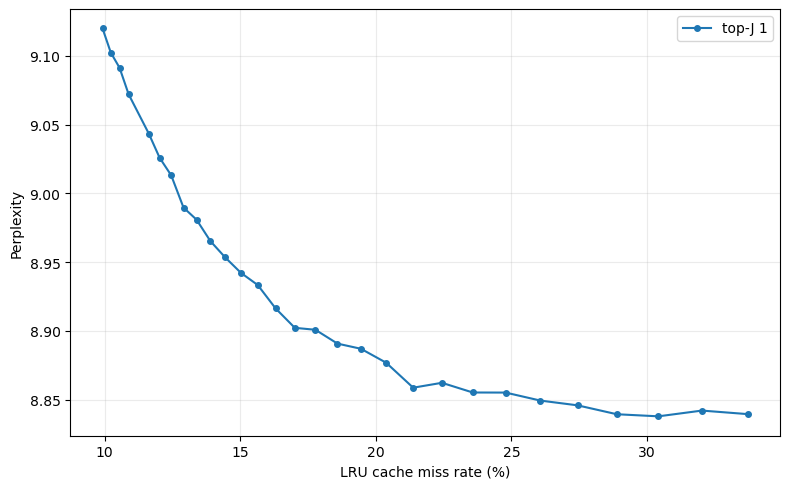

In [3]:
# PPL vs cache miss rate
fig, ax = plt.subplots(figsize=(8, 5))
for top_j, points in SWEEP.items():
    if top_j != '1':
        continue
    lambdas, ppl, miss = zip(*points)
    ax.plot([100 * x for x in miss], ppl, marker=MARKERS[int(top_j)], ms=4, color=COLORS[int(top_j)], label=f'top-J {top_j}')
ax.set_xlabel('LRU cache miss rate (%)')
ax.set_ylabel('Perplexity')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()


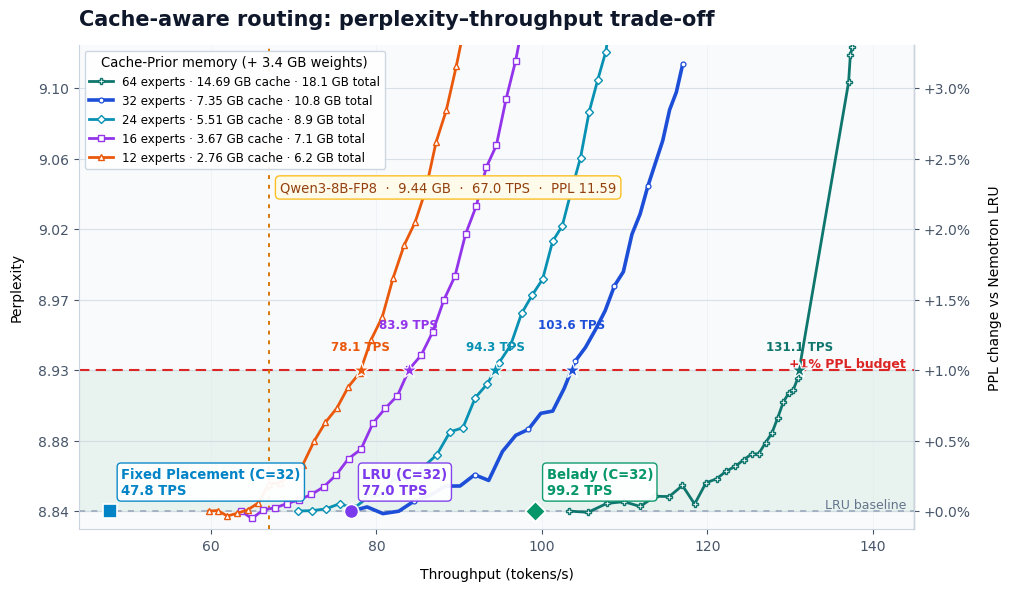

In [4]:
# PPL vs TPS — zoomed sweep with dual y-axes and direct annotations
import numpy as np

def ppl_pct(ppl):
    return 100.0 * (np.asarray(ppl) / NEMOTRON_BASELINE_PPL - 1.0)

def ppl_from_pct(pct):
    return NEMOTRON_BASELINE_PPL * (1.0 + np.asarray(pct) / 100.0)

TOP_J = "1"
lambdas, ppl, miss = (np.array(v) for v in zip(*SWEEP[TOP_J]))
proxy = throughput_proxy(miss, cpu=True)

lru = next(r for r in REFERENCES if "LRU" in r["label"])
belady = next(r for r in REFERENCES if "Belady" in r["label"])
fp = next(r for r in REFERENCES if "Fixed Placement" in r["label"])
one_pct_ppl = NEMOTRON_BASELINE_PPL * 1.01

def tps_at_ppl_budget(tps, ppl_values, budget):
    sign_change = np.flatnonzero(np.diff(np.sign(ppl_values - budget)))
    if not len(sign_change):
        return None
    i = sign_change[0]
    t = (budget - ppl_values[i]) / (ppl_values[i + 1] - ppl_values[i])
    return float(tps[i] + t * (tps[i + 1] - tps[i]))

x_cross = tps_at_ppl_budget(proxy, ppl, one_pct_ppl)

refs = [
    ("LRU (C=32)", lru["proxy"], lru["ppl"], "o", "#7c3aed"),
    ("Belady (C=32)", belady["proxy"], belady["ppl"], "D", "#059669"),
    ("Fixed Placement (C=32)", fp["proxy"], fp["ppl"], "s", "#0284c7"),
]

def cache_legend_label(capacity):
    memory = CACHE_MEMORY_GB[capacity]
    return (
        f"{capacity} experts · {memory['cache']:.2f} GB cache · "
        f"{memory['with_weights']:.1f} GB total"
    )

fig, ax = plt.subplots(figsize=(10, 5.8), layout="constrained")
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8fafc")

# Lightly shade the region within the 1% perplexity budget.
ax.axhspan(NEMOTRON_BASELINE_PPL, one_pct_ppl, color="#16a34a", alpha=0.07, zorder=0)
cache32_line, = ax.plot(
    proxy, ppl, color="#1d4ed8", linewidth=2.6, label=cache_legend_label(32),
    marker="o", markersize=3.5, markevery=4,
    markerfacecolor="white", markeredgewidth=0.9, zorder=3,
)

capacity_styles = {
    64: ("#0f766e", "P"),
    24: ("#0891b2", "D"),
    16: ("#9333ea", "s"),
    12: ("#ea580c", "^"),
}
capacity_lines = {}
for capacity, (color, marker) in capacity_styles.items():
    capacity_data = np.asarray(CACHE_CAPACITY_SWEEP[capacity])
    capacity_lines[capacity], = ax.plot(
        capacity_data[:, 3], capacity_data[:, 1],
        color=color, linewidth=2.0, label=cache_legend_label(capacity),
        marker=marker, markersize=4.5, markerfacecolor="white",
        markeredgewidth=1.0, zorder=2,
    )

ax.axhline(
    NEMOTRON_BASELINE_PPL, color="#94a3b8", linewidth=1.1,
    linestyle=(0, (4, 4)), zorder=1,
)
ax.text(
    0.99, NEMOTRON_BASELINE_PPL, "LRU baseline",
    transform=ax.get_yaxis_transform(), ha="right", va="bottom",
    color="#64748b", fontsize=9,
)
ax.axhline(
    one_pct_ppl, color="#dc2626", linewidth=1.5,
    linestyle=(0, (5, 3)), zorder=1,
)
ax.text(
    0.99, one_pct_ppl, "+1% PPL budget",
    transform=ax.get_yaxis_transform(), ha="right", va="bottom",
    color="#dc2626", fontsize=9, fontweight="semibold",
)

ax.axvline(
    QWEN["proxy"], color="#d97706", linewidth=1.4,
    linestyle=(0, (2, 3)), zorder=1,
)
ax.annotate(
    f"Qwen3-8B-FP8  ·  {QWEN['weights_gb']:.2f} GB  ·  "
    f"{QWEN['proxy']:.1f} TPS  ·  PPL {QWEN['ppl']:.2f}",
    xy=(QWEN["proxy"], 0.72), xycoords=("data", "axes fraction"),
    xytext=(8, 0), textcoords="offset points",
    ha="left", va="top", color="#92400e", fontsize=9.5,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#fffbeb", edgecolor="#fbbf24"),
)

label_offsets = {
    "LRU (C=32)": (8, 10),
    "Belady (C=32)": (8, 10),
    "Fixed Placement (C=32)": (8, 10),
}
for name, x, y, marker, color in refs:
    ax.scatter(
        x, y, marker=marker, s=105, color=color,
        edgecolors="white", linewidths=1.2, zorder=4,
    )
    ax.annotate(
        f"{name}\n{x:.1f} TPS",
        xy=(x, y), xytext=label_offsets[name], textcoords="offset points",
        ha="left", va="bottom", color=color, fontsize=9.5, fontweight="semibold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=color, alpha=0.95),
    )

budget_crossings = []
for capacity in (64, 32, 24, 16, 12):
    if capacity == 32:
        crossing, color = x_cross, "#1d4ed8"
    else:
        color = capacity_styles[capacity][0]
        capacity_data = np.asarray(CACHE_CAPACITY_SWEEP[capacity])
        crossing = tps_at_ppl_budget(capacity_data[:, 3], capacity_data[:, 1], one_pct_ppl)
    budget_crossings.append((capacity, crossing, color))

label_y_offsets = {64: 12, 32: 28, 24: 12, 16: 28, 12: 12}
for capacity, crossing, color in budget_crossings:
    if crossing is None:
        continue
    ax.scatter(
        crossing, one_pct_ppl, marker="*", s=145, color=color,
        edgecolors="white", linewidths=0.9, zorder=5,
    )
    ax.annotate(
        f"{crossing:.1f} TPS",
        xy=(crossing, one_pct_ppl),
        xytext=(0, label_y_offsets[capacity]), textcoords="offset points",
        ha="center", va="bottom", color=color, fontsize=8.5, fontweight="semibold",
    )

ax.set_xlim(44, 145)
ax.set_ylim(8.828, 9.132)

pct_ticks = np.arange(0.0, 3.01, 0.5)
ppl_ticks = ppl_from_pct(pct_ticks)
ax.set_yticks(ppl_ticks)
ax.set_yticklabels([f"{v:.2f}" for v in ppl_ticks])

sec = ax.secondary_yaxis("right", functions=(ppl_pct, ppl_from_pct))
sec.set_yticks(pct_ticks)
sec.set_yticklabels([f"{v:+.1f}%" for v in pct_ticks])
sec.set_ylabel("PPL change vs Nemotron LRU", labelpad=12)

ax.set_title("Cache-aware routing: perplexity–throughput trade-off", loc="left", pad=14,
             fontsize=15, fontweight="bold", color="#0f172a")
legend_order = (64, 32, 24, 16, 12)
legend_handles = [
    cache32_line if capacity == 32 else capacity_lines[capacity]
    for capacity in legend_order
]
ax.legend(
    handles=legend_handles,
    labels=[cache_legend_label(capacity) for capacity in legend_order],
    loc="upper left", title=f"Cache-Prior memory (+ {WEIGHTS_MEMORY_GB:.1f} GB weights)",
    frameon=True, facecolor="white", edgecolor="#cbd5e1",
    framealpha=0.95, fontsize=8.5, title_fontsize=9.5,
)
ax.set_xlabel("Throughput (tokens/s)", labelpad=10)
ax.set_ylabel("Perplexity", labelpad=10)
ax.grid(axis="y", color="#cbd5e1", linewidth=0.8, alpha=0.7)
ax.grid(axis="x", color="#e2e8f0", linewidth=0.6, alpha=0.45)
ax.set_axisbelow(True)
ax.tick_params(colors="#475569")
sec.tick_params(colors="#475569")
for spine in ax.spines.values():
    spine.set_color("#cbd5e1")
ax.spines["top"].set_visible(False)
sec.spines["top"].set_visible(False)


In [5]:
# Optional: save the current figure
# fig.savefig('../outputs/cache-prior-ppl-vs-proxy.png', dpi=200, bbox_inches='tight')
# Cache-capacity sweeps, top-J=1: (lambda, perplexity, miss rate, TPS proxy)
# Miss rates are fractions. The primary TPS value uses CPU-computed misses.
# Both cards include all measured capacities 16/32/64/72/96.
# Capacity 96 is retained for 5070 plotting but is physically infeasible.

CARD_SPECS = {
    "5070": {"vram_gb": 12, "bandwidth_gbps": 550},
    "5070 Ti": {"vram_gb": 16, "bandwidth_gbps": 735},
}

CACHE_CAPACITY_FITS = {
    "5070": {16: True, 32: True, 64: True, 72: True, 96: False},
    "5070 Ti": {16: True, 32: True, 64: True, 72: True, 96: True},
}

def throughput_proxy(miss_rate, card="5070", cpu=True):
    vram_bw = CARD_SPECS[card]["bandwidth_gbps"]
    gpu_read_gb = 2.2 + 0.774 * ((1.0 - miss_rate) if cpu else 1.0)
    miss_bw = 65 if cpu else 40
    latency_ms = gpu_read_gb / vram_bw * 1000 + 0.774 * miss_rate / miss_bw * 1000
    return 1000 / latency_ms

CACHE_CAPACITY_SWEEP = {
    "5070": {
        16: [
            (0.000000, 8.95512650, 0.48512622, 95.23),
            (0.010101, 8.95705515, 0.46600946, 97.08),
            (0.020202, 8.95394967, 0.44694765, 99.01),
            (0.030303, 8.96059140, 0.42817769, 100.98),
            (0.040404, 8.96180435, 0.40976996, 102.99),
            (0.050505, 8.97000146, 0.39199103, 105.01),
            (0.060606, 8.97367487, 0.37490107, 107.02),
            (0.070707, 8.98057279, 0.35841228, 109.04),
            (0.080808, 8.99128773, 0.34270964, 111.04),
            (0.090909, 9.00355029, 0.32778760, 113.00),
            (0.101010, 9.01002440, 0.31360086, 114.94),
            (0.111111, 9.02200199, 0.30014532, 116.84),
            (0.121212, 9.03262843, 0.28739481, 118.69),
            (0.131313, 9.04936734, 0.27540040, 120.50),
            (0.141414, 9.07211212, 0.26400857, 122.26),
            (0.151515, 9.09400184, 0.25329662, 123.96),
            (0.161616, 9.11774529, 0.24310769, 125.63),
            (0.171717, 9.14031384, 0.23348810, 127.24),
            (0.181818, 9.16427459, 0.22434237, 128.82),
            (0.191919, 9.19304739, 0.21576155, 130.33),
            (0.202020, 9.21408440, 0.20760423, 131.80),
            (0.212121, 9.24226992, 0.19977388, 133.24),
            (0.222222, 9.27247007, 0.19242744, 134.63),
            (0.232323, 9.30198953, 0.18545304, 135.97),
            (0.242424, 9.32731678, 0.17879707, 137.27),
            (0.252525, 9.35922026, 0.17254822, 138.52),
            (0.262626, 9.38944169, 0.16658421, 139.73),
            (0.272727, 9.42485106, 0.16085073, 140.92),
            (0.282828, 9.45583513, 0.15538656, 142.07),
            (0.292929, 9.48834540, 0.15038068, 143.14),
            (0.303030, 9.52749214, 0.14551524, 144.19),
            (0.313131, 9.56661329, 0.14088043, 145.21),
            (0.323232, 9.61161792, 0.13657581, 146.17),
            (0.333333, 9.65181949, 0.13243287, 147.10),
            (0.343434, 9.68799562, 0.12850581, 148.00),
            (0.353535, 9.74039725, 0.12481759, 148.86),
            (0.363636, 9.77578717, 0.12127925, 149.68),
            (0.373737, 9.82992842, 0.11800205, 150.46),
            (0.383838, 9.87426788, 0.11486731, 151.21),
            (0.393939, 9.91753298, 0.11185463, 151.93),
            (0.404040, 9.96400393, 0.10905792, 152.62),
            (0.414141, 10.01821749, 0.10631250, 153.29),
            (0.424242, 10.05696084, 0.10380546, 153.91),
            (0.434343, 10.12969728, 0.10142763, 154.50),
            (0.444444, 10.18294204, 0.09914572, 155.08),
            (0.454545, 10.21521953, 0.09699300, 155.62),
            (0.464646, 10.28393306, 0.09497917, 156.14),
            (0.474747, 10.32889021, 0.09306343, 156.63),
            (0.484848, 10.37104199, 0.09119252, 157.11),
            (0.494949, 10.42480137, 0.08947121, 157.56),
            (0.505051, 10.48388172, 0.08786023, 157.98),
            (0.515152, 10.50944192, 0.08629697, 158.39),
            (0.525253, 10.56939407, 0.08481251, 158.78),
            (0.535354, 10.62779536, 0.08338087, 159.16),
            (0.545455, 10.65791376, 0.08208442, 159.51),
            (0.555556, 10.71027648, 0.08081309, 159.85),
            (0.565657, 10.77174151, 0.07960082, 160.18),
            (0.575758, 10.81006156, 0.07844995, 160.49),
            (0.585859, 10.87737471, 0.07737111, 160.78),
            (0.595960, 10.91625930, 0.07639154, 161.05),
            (0.606061, 10.97004234, 0.07538476, 161.32),
            (0.616162, 11.01988861, 0.07449284, 161.56),
            (0.626263, 11.08495247, 0.07358522, 161.81),
            (0.636364, 11.10614214, 0.07278605, 162.03),
            (0.646465, 11.14062161, 0.07206083, 162.23),
            (0.656566, 11.17519625, 0.07134707, 162.43),
            (0.666667, 11.23461405, 0.07066975, 162.62),
            (0.676768, 11.27328929, 0.07004213, 162.79),
            (0.686869, 11.31277738, 0.06943215, 162.96),
            (0.696970, 11.34513581, 0.06893149, 163.10),
            (0.707071, 11.39935033, 0.06839021, 163.25),
            (0.717172, 11.45103463, 0.06788275, 163.40),
            (0.727273, 11.47060515, 0.06743308, 163.52),
            (0.737374, 11.51968699, 0.06703669, 163.63),
            (0.747475, 11.55267641, 0.06668239, 163.73),
            (0.757576, 11.58897602, 0.06631515, 163.84),
            (0.767677, 11.62164332, 0.06604410, 163.91),
            (0.777778, 11.66306714, 0.06573877, 164.00),
            (0.787879, 11.71019193, 0.06549802, 164.07),
            (0.797980, 11.74901858, 0.06525165, 164.14),
            (0.808081, 11.78511969, 0.06505031, 164.19),
            (0.818182, 11.80398145, 0.06484035, 164.25),
            (0.828283, 11.85848060, 0.06464882, 164.31),
            (0.838384, 11.87483489, 0.06452372, 164.34),
            (0.848485, 11.90724954, 0.06439188, 164.38),
            (0.858586, 11.92603557, 0.06428780, 164.41),
            (0.868687, 11.95954860, 0.06416145, 164.45),
            (0.878788, 11.98367864, 0.06405775, 164.48),
            (0.888889, 12.01503816, 0.06400570, 164.49),
            (0.898990, 12.04081443, 0.06391767, 164.52),
            (0.909091, 12.08051908, 0.06382789, 164.54),
            (0.919192, 12.10228844, 0.06378168, 164.55),
            (0.929293, 12.11760814, 0.06372955, 164.57),
            (0.939394, 12.13823242, 0.06368852, 164.58),
            (0.949495, 12.15650017, 0.06365123, 164.59),
            (0.959596, 12.17435769, 0.06362274, 164.60),
            (0.969697, 12.17820509, 0.06360205, 164.61),
            (0.979798, 12.18909770, 0.06359632, 164.61),
            (0.989899, 12.19617369, 0.06359443, 164.61),
            (1.000000, 12.18755500, 0.06357401, 164.61),
        ],
        32: [
            (0.000000, 8.95811901, 0.34006966, 111.38),
            (0.010101, 8.95814327, 0.32095931, 113.93),
            (0.020202, 8.95638468, 0.30274359, 116.47),
            (0.030303, 8.96442860, 0.28553159, 118.97),
            (0.040404, 8.96576910, 0.26943578, 121.41),
            (0.050505, 8.96788970, 0.25445167, 123.78),
            (0.060606, 8.97367964, 0.24057821, 126.05),
            (0.070707, 8.98402264, 0.22759022, 128.25),
            (0.080808, 8.98763626, 0.21557326, 130.36),
            (0.090909, 8.99916966, 0.20444205, 132.38),
            (0.101010, 9.00797770, 0.19414921, 134.30),
            (0.111111, 9.02095544, 0.18459191, 136.14),
            (0.121212, 9.02581062, 0.17573248, 137.88),
            (0.131313, 9.03835281, 0.16751745, 139.54),
            (0.141414, 9.05411356, 0.15980694, 141.14),
            (0.151515, 9.06730132, 0.15266966, 142.65),
            (0.161616, 9.09223998, 0.14594545, 144.10),
            (0.171717, 9.09655934, 0.13962665, 145.49),
            (0.181818, 9.11441251, 0.13374531, 146.81),
            (0.191919, 9.12691669, 0.12825319, 148.06),
            (0.202020, 9.14545363, 0.12309795, 149.26),
            (0.212121, 9.16822677, 0.11816744, 150.42),
            (0.222222, 9.18362852, 0.11357414, 151.52),
            (0.232323, 9.20257298, 0.10925576, 152.57),
            (0.242424, 9.21989597, 0.10517923, 153.57),
            (0.252525, 9.24222126, 0.10131348, 154.53),
            (0.262626, 9.26769663, 0.09770684, 155.44),
            (0.272727, 9.29241020, 0.09430436, 156.31),
            (0.282828, 9.31140979, 0.09113031, 157.13),
            (0.292929, 9.33788219, 0.08814791, 157.91),
            (0.303030, 9.35866258, 0.08534967, 158.64),
            (0.313131, 9.38648897, 0.08272719, 159.34),
            (0.323232, 9.41495475, 0.08020202, 160.01),
            (0.333333, 9.44283570, 0.07786623, 160.65),
            (0.343434, 9.47255936, 0.07566020, 161.25),
            (0.353535, 9.49288599, 0.07358910, 161.81),
            (0.363636, 9.52855848, 0.07166181, 162.34),
            (0.373737, 9.55578873, 0.06982316, 162.85),
            (0.383838, 9.58624369, 0.06808106, 163.34),
            (0.393939, 9.61741251, 0.06647096, 163.79),
            (0.404040, 9.64900439, 0.06490051, 164.24),
            (0.414141, 9.68189501, 0.06350466, 164.63),
            (0.424242, 9.70986475, 0.06212692, 165.03),
            (0.434343, 9.74789270, 0.06089162, 165.38),
            (0.444444, 9.75942908, 0.05967990, 165.73),
            (0.454545, 9.78803311, 0.05850489, 166.07),
            (0.464646, 9.83592038, 0.05742291, 166.38),
            (0.474747, 9.85501647, 0.05644449, 166.67),
            (0.484848, 9.88758518, 0.05546675, 166.95),
            (0.494949, 9.92185667, 0.05460980, 167.20),
            (0.505051, 9.94680197, 0.05373344, 167.46),
            (0.515152, 9.96166566, 0.05293282, 167.70),
            (0.525253, 9.99213171, 0.05212254, 167.94),
            (0.535354, 10.03654633, 0.05142546, 168.14),
            (0.545455, 10.05656963, 0.05075824, 168.34),
            (0.555556, 10.09282324, 0.05010404, 168.54),
            (0.565657, 10.12267889, 0.04953317, 168.71),
            (0.575758, 10.16405644, 0.04897803, 168.87),
            (0.585859, 10.16871093, 0.04842267, 169.04),
            (0.595960, 10.20183887, 0.04793928, 169.19),
            (0.606061, 10.22666002, 0.04747695, 169.33),
            (0.616162, 10.25007644, 0.04701144, 169.47),
            (0.626263, 10.27745438, 0.04665564, 169.57),
            (0.636364, 10.30726744, 0.04624205, 169.70),
            (0.646465, 10.31384186, 0.04590858, 169.80),
            (0.656566, 10.34735926, 0.04557917, 169.90),
            (0.666667, 10.36600721, 0.04524807, 170.00),
            (0.676768, 10.38667157, 0.04498046, 170.08),
            (0.686869, 10.40238345, 0.04472915, 170.16),
            (0.696970, 10.42955050, 0.04448925, 170.23),
            (0.707071, 10.45276964, 0.04423108, 170.31),
            (0.717172, 10.46646612, 0.04404372, 170.36),
            (0.727273, 10.48600478, 0.04387637, 170.42),
            (0.737374, 10.51376804, 0.04368579, 170.47),
            (0.747475, 10.53976487, 0.04351795, 170.53),
            (0.757576, 10.55608024, 0.04337203, 170.57),
            (0.767677, 10.58291159, 0.04324450, 170.61),
            (0.777778, 10.60434866, 0.04313908, 170.64),
            (0.787879, 10.63099254, 0.04302780, 170.68),
            (0.797980, 10.64309817, 0.04293576, 170.70),
            (0.808081, 10.65211291, 0.04286069, 170.73),
            (0.818182, 10.68800436, 0.04275874, 170.76),
            (0.828283, 10.69852503, 0.04270000, 170.78),
            (0.838384, 10.70937677, 0.04262095, 170.80),
            (0.848485, 10.73432542, 0.04256126, 170.82),
            (0.858586, 10.75368317, 0.04251548, 170.83),
            (0.868687, 10.76755278, 0.04246853, 170.85),
            (0.878788, 10.78897869, 0.04242467, 170.86),
            (0.888889, 10.80326755, 0.04238361, 170.87),
            (0.898990, 10.82296027, 0.04235544, 170.88),
            (0.909091, 10.83464067, 0.04233563, 170.89),
            (0.919192, 10.84890501, 0.04229769, 170.90),
            (0.929293, 10.86096178, 0.04226378, 170.91),
            (0.939394, 10.87139946, 0.04224776, 170.91),
            (0.949495, 10.88781663, 0.04222068, 170.92),
            (0.959596, 10.89294577, 0.04221381, 170.92),
            (0.969697, 10.89849891, 0.04219743, 170.93),
            (0.979798, 10.90451506, 0.04220049, 170.93),
            (0.989899, 10.91319200, 0.04219017, 170.93),
            (1.000000, 10.90765076, 0.04219464, 170.93),
        ],
        64: [
            (0.000000, 8.95776847, 0.16126858, 140.83),
            (0.010101, 8.95817899, 0.14800711, 143.65),
            (0.020202, 8.96087824, 0.13626999, 146.24),
            (0.030303, 8.96137329, 0.12582655, 148.62),
            (0.040404, 8.96615399, 0.11653282, 150.81),
            (0.050505, 8.96721187, 0.10827841, 152.81),
            (0.060606, 8.97139794, 0.10094859, 154.62),
            (0.070707, 8.97439095, 0.09438510, 156.29),
            (0.080808, 8.98022360, 0.08854067, 157.80),
            (0.090909, 8.98604809, 0.08322949, 159.20),
            (0.101010, 8.98959522, 0.07849417, 160.48),
            (0.111111, 8.99064992, 0.07416831, 161.65),
            (0.121212, 9.00059300, 0.07021429, 162.75),
            (0.131313, 9.00990757, 0.06663967, 163.75),
            (0.141414, 9.01547468, 0.06334386, 164.68),
            (0.151515, 9.01952872, 0.06037172, 165.53),
            (0.161616, 9.02327331, 0.05757514, 166.34),
            (0.171717, 9.03261048, 0.05502339, 167.08),
            (0.181818, 9.03844691, 0.05264171, 167.78),
            (0.191919, 9.04521371, 0.05045940, 168.43),
            (0.202020, 9.05158564, 0.04846380, 169.03),
            (0.212121, 9.05972368, 0.04661519, 169.58),
            (0.222222, 9.07538241, 0.04489647, 170.11),
            (0.232323, 9.09078993, 0.04324343, 170.61),
            (0.242424, 9.09677098, 0.04173793, 171.07),
            (0.252525, 9.10376527, 0.04034254, 171.50),
            (0.262626, 9.12033068, 0.03904882, 171.90),
            (0.272727, 9.12581067, 0.03783211, 172.28),
            (0.282828, 9.14443212, 0.03670236, 172.63),
            (0.292929, 9.15836986, 0.03566154, 172.96),
            (0.303030, 9.17013947, 0.03468030, 173.27),
            (0.313131, 9.17653752, 0.03375317, 173.56),
            (0.323232, 9.19955977, 0.03290724, 173.83),
            (0.333333, 9.21455272, 0.03212030, 174.08),
            (0.343434, 9.22669179, 0.03135894, 174.32),
            (0.353535, 9.24497021, 0.03065626, 174.55),
            (0.363636, 9.26337310, 0.03000987, 174.75),
            (0.373737, 9.27000315, 0.02941643, 174.94),
            (0.383838, 9.29262991, 0.02882566, 175.13),
            (0.393939, 9.30509763, 0.02829203, 175.30),
            (0.404040, 9.32576350, 0.02780398, 175.46),
            (0.414141, 9.33013193, 0.02734456, 175.61),
            (0.424242, 9.35633768, 0.02690619, 175.75),
            (0.434343, 9.36744222, 0.02648646, 175.89),
            (0.444444, 9.38418633, 0.02610358, 176.01),
            (0.454545, 9.40400253, 0.02574936, 176.13),
            (0.464646, 9.42457303, 0.02540945, 176.24),
            (0.474747, 9.43499491, 0.02509235, 176.34),
            (0.484848, 9.44615253, 0.02478295, 176.44),
            (0.494949, 9.46478241, 0.02450631, 176.53),
            (0.505051, 9.48410572, 0.02425063, 176.62),
            (0.515152, 9.48947544, 0.02403308, 176.69),
            (0.525253, 9.51873318, 0.02380849, 176.76),
            (0.535354, 9.53675161, 0.02358690, 176.84),
            (0.545455, 9.55202721, 0.02341013, 176.89),
            (0.555556, 9.55734052, 0.02324038, 176.95),
            (0.565657, 9.57557294, 0.02304729, 177.01),
            (0.575758, 9.59781673, 0.02290095, 177.06),
            (0.585859, 9.60507732, 0.02275852, 177.11),
            (0.595960, 9.63226542, 0.02263954, 177.15),
            (0.606061, 9.64738646, 0.02249558, 177.20),
            (0.616162, 9.65879180, 0.02240258, 177.23),
            (0.626263, 9.66969828, 0.02229826, 177.26),
            (0.636364, 9.68205333, 0.02218959, 177.30),
            (0.646465, 9.69039092, 0.02210891, 177.32),
            (0.656566, 9.70855253, 0.02200903, 177.36),
            (0.666667, 9.71571358, 0.02192865, 177.38),
            (0.676768, 9.72755925, 0.02184769, 177.41),
            (0.686869, 9.73856167, 0.02178660, 177.43),
            (0.696970, 9.75170190, 0.02172327, 177.45),
            (0.707071, 9.75746962, 0.02167711, 177.47),
            (0.717172, 9.76818594, 0.02163096, 177.48),
            (0.727273, 9.77811938, 0.02157456, 177.50),
            (0.737374, 9.79376532, 0.02153750, 177.51),
            (0.747475, 9.80315777, 0.02149093, 177.53),
            (0.757576, 9.81372680, 0.02146017, 177.54),
            (0.767677, 9.83050690, 0.02141950, 177.55),
            (0.777778, 9.84302572, 0.02138630, 177.56),
            (0.787879, 9.85150560, 0.02136471, 177.57),
            (0.797980, 9.86474470, 0.02133753, 177.58),
            (0.808081, 9.88110316, 0.02131211, 177.59),
            (0.818182, 9.89209731, 0.02129767, 177.59),
            (0.828283, 9.90254214, 0.02127499, 177.60),
            (0.838384, 9.91477278, 0.02124911, 177.61),
            (0.848485, 9.92410592, 0.02123186, 177.61),
            (0.858586, 9.93379393, 0.02121483, 177.62),
            (0.868687, 9.94267863, 0.02120105, 177.62),
            (0.878788, 9.95463909, 0.02118833, 177.63),
            (0.888889, 9.96216045, 0.02117768, 177.63),
            (0.898990, 9.97462498, 0.02117427, 177.63),
            (0.909091, 9.98490689, 0.02115568, 177.64),
            (0.919192, 9.99770600, 0.02114755, 177.64),
            (0.929293, 10.00148964, 0.02114392, 177.64),
            (0.939394, 10.00771977, 0.02113182, 177.65),
            (0.949495, 10.01011699, 0.02112437, 177.65),
            (0.959596, 10.01628653, 0.02112312, 177.65),
            (0.969697, 10.01833375, 0.02112074, 177.65),
            (0.979798, 10.01963485, 0.02111856, 177.65),
            (0.989899, 10.02277305, 0.02112011, 177.65),
            (1.000000, 10.02116486, 0.02111163, 177.65),
        ],
        72: [
            (0.000000, 8.95390555, 0.12929218, 147.82),
            (0.010101, 8.95900439, 0.11803551, 150.45),
            (0.020202, 8.95813456, 0.10819180, 152.83),
            (0.030303, 8.96725479, 0.09958688, 154.97),
            (0.040404, 8.96736509, 0.09210701, 156.88),
            (0.050505, 8.96978064, 0.08547253, 158.61),
            (0.060606, 8.96428732, 0.07960604, 160.18),
            (0.070707, 8.97148844, 0.07441384, 161.59),
            (0.080808, 8.97836478, 0.06976546, 162.87),
            (0.090909, 8.98278526, 0.06564018, 164.03),
            (0.101010, 8.98361293, 0.06194453, 165.08),
            (0.111111, 8.98711333, 0.05858913, 166.04),
            (0.121212, 8.98859642, 0.05555421, 166.93),
            (0.131313, 8.99831084, 0.05277112, 167.75),
            (0.141414, 9.00324198, 0.05023146, 168.50),
            (0.151515, 9.01144561, 0.04795891, 169.18),
            (0.161616, 9.01379270, 0.04583270, 169.82),
            (0.171717, 9.01691007, 0.04387389, 170.42),
            (0.181818, 9.02854273, 0.04207138, 170.97),
            (0.191919, 9.03338067, 0.04045893, 171.46),
            (0.202020, 9.04244907, 0.03891799, 171.94),
            (0.212121, 9.04874767, 0.03753958, 172.37),
            (0.222222, 9.06176380, 0.03622094, 172.78),
            (0.232323, 9.06977412, 0.03501198, 173.16),
            (0.242424, 9.07713318, 0.03388012, 173.52),
            (0.252525, 9.08972842, 0.03283900, 173.85),
            (0.262626, 9.09693008, 0.03186591, 174.16),
            (0.272727, 9.10948185, 0.03096370, 174.45),
            (0.282828, 9.11341445, 0.03012440, 174.72),
            (0.292929, 9.12775301, 0.02934838, 174.96),
            (0.303030, 9.14260997, 0.02862122, 175.20),
            (0.313131, 9.15262370, 0.02793505, 175.42),
            (0.323232, 9.16852902, 0.02731464, 175.62),
            (0.333333, 9.18054410, 0.02673218, 175.81),
            (0.343434, 9.19217145, 0.02616423, 175.99),
            (0.353535, 9.20427686, 0.02566455, 176.16),
            (0.363636, 9.22093900, 0.02515649, 176.32),
            (0.373737, 9.23223194, 0.02470516, 176.47),
            (0.383838, 9.26075392, 0.02429176, 176.61),
            (0.393939, 9.26436157, 0.02388216, 176.74),
            (0.404040, 9.27574204, 0.02351880, 176.86),
            (0.414141, 9.29006586, 0.02317776, 176.97),
            (0.424242, 9.31503810, 0.02287303, 177.07),
            (0.434343, 9.32875619, 0.02256150, 177.17),
            (0.444444, 9.34064331, 0.02227672, 177.27),
            (0.454545, 9.35500422, 0.02200789, 177.36),
            (0.464646, 9.36967325, 0.02176812, 177.44),
            (0.474747, 9.37615228, 0.02153081, 177.51),
            (0.484848, 9.39490460, 0.02132909, 177.58),
            (0.494949, 9.41067745, 0.02110748, 177.65),
            (0.505051, 9.43289822, 0.02092850, 177.71),
            (0.515152, 9.44019969, 0.02075547, 177.77),
            (0.525253, 9.45603600, 0.02061399, 177.82),
            (0.535354, 9.48083178, 0.02045019, 177.87),
            (0.545455, 9.49589845, 0.02031521, 177.92),
            (0.555556, 9.49867161, 0.02018163, 177.96),
            (0.565657, 9.51653691, 0.02005486, 178.00),
            (0.575758, 9.54081518, 0.01994958, 178.04),
            (0.585859, 9.54967289, 0.01985675, 178.07),
            (0.595960, 9.57190729, 0.01975584, 178.10),
            (0.606061, 9.58310206, 0.01967403, 178.13),
            (0.616162, 9.59869711, 0.01958974, 178.16),
            (0.626263, 9.61177855, 0.01952000, 178.18),
            (0.636364, 9.61076615, 0.01942201, 178.21),
            (0.646465, 9.61818847, 0.01936624, 178.23),
            (0.656566, 9.63217505, 0.01930262, 178.25),
            (0.666667, 9.64032485, 0.01925051, 178.27),
            (0.676768, 9.65846262, 0.01920353, 178.29),
            (0.686869, 9.67294265, 0.01916062, 178.30),
            (0.696970, 9.67555721, 0.01911605, 178.32),
            (0.707071, 9.68414401, 0.01907947, 178.33),
            (0.717172, 9.69304830, 0.01905008, 178.34),
            (0.727273, 9.70031495, 0.01902521, 178.35),
            (0.737374, 9.70724641, 0.01898656, 178.36),
            (0.747475, 9.72136809, 0.01895670, 178.37),
            (0.757576, 9.73581157, 0.01893289, 178.38),
            (0.767677, 9.75236627, 0.01889793, 178.39),
            (0.777778, 9.76752500, 0.01887282, 178.40),
            (0.787879, 9.78055054, 0.01884743, 178.41),
            (0.797980, 9.78655519, 0.01883408, 178.41),
            (0.808081, 9.79927177, 0.01881918, 178.42),
            (0.818182, 9.81192740, 0.01879827, 178.42),
            (0.828283, 9.82018169, 0.01878910, 178.43),
            (0.838384, 9.82984219, 0.01877641, 178.43),
            (0.848485, 9.83658346, 0.01876363, 178.43),
            (0.858586, 9.84894285, 0.01874775, 178.44),
            (0.868687, 9.86114405, 0.01873983, 178.44),
            (0.878788, 9.87543399, 0.01873011, 178.45),
            (0.888889, 9.87695935, 0.01872121, 178.45),
            (0.898990, 9.88867213, 0.01870907, 178.45),
            (0.909091, 9.89861907, 0.01870162, 178.46),
            (0.919192, 9.90609211, 0.01869659, 178.46),
            (0.929293, 9.90858843, 0.01868963, 178.46),
            (0.939394, 9.91604879, 0.01868535, 178.46),
            (0.949495, 9.92352305, 0.01868196, 178.46),
            (0.959596, 9.92563642, 0.01867582, 178.46),
            (0.969697, 9.92748528, 0.01867533, 178.46),
            (0.979798, 9.92967875, 0.01867225, 178.47),
            (0.989899, 9.93083384, 0.01867866, 178.46),
            (1.000000, 9.93200368, 0.01867085, 178.47),
        ],
        96: [
            (0.000000, 8.95872479, 0.05849673, 166.07),
            (0.010101, 8.95873560, 0.05333342, 167.58),
            (0.020202, 8.96324796, 0.04905233, 168.85),
            (0.030303, 8.96292156, 0.04543355, 169.94),
            (0.040404, 8.96302754, 0.04235523, 170.88),
            (0.050505, 8.96553676, 0.03972712, 171.69),
            (0.060606, 8.96433926, 0.03744311, 172.40),
            (0.070707, 8.96529445, 0.03548054, 173.02),
            (0.080808, 8.96810086, 0.03374799, 173.56),
            (0.090909, 8.96868314, 0.03220918, 174.05),
            (0.101010, 8.97650443, 0.03088069, 174.47),
            (0.111111, 8.97791166, 0.02962740, 174.87),
            (0.121212, 8.97899287, 0.02853005, 175.23),
            (0.131313, 8.98404954, 0.02753711, 175.55),
            (0.141414, 8.98509298, 0.02664655, 175.84),
            (0.151515, 8.99196043, 0.02582655, 176.10),
            (0.161616, 8.98964582, 0.02504524, 176.36),
            (0.171717, 8.99132613, 0.02435107, 176.59),
            (0.181818, 9.00267302, 0.02371251, 176.80),
            (0.191919, 9.00836056, 0.02313414, 176.99),
            (0.202020, 9.01417019, 0.02259082, 177.16),
            (0.212121, 9.01892009, 0.02207623, 177.33),
            (0.222222, 9.02689269, 0.02160612, 177.49),
            (0.232323, 9.03251485, 0.02118841, 177.63),
            (0.242424, 9.04610876, 0.02077302, 177.77),
            (0.252525, 9.05146070, 0.02038629, 177.89),
            (0.262626, 9.05953120, 0.02002184, 178.01),
            (0.272727, 9.06411549, 0.01970425, 178.12),
            (0.282828, 9.06936308, 0.01939944, 178.22),
            (0.292929, 9.07888062, 0.01910491, 178.32),
            (0.303030, 9.08561538, 0.01882988, 178.41),
            (0.313131, 9.09740673, 0.01857930, 178.50),
            (0.323232, 9.10479470, 0.01834497, 178.57),
            (0.333333, 9.11767256, 0.01813596, 178.64),
            (0.343434, 9.13440976, 0.01793029, 178.71),
            (0.353535, 9.14759254, 0.01772901, 178.78),
            (0.363636, 9.15836147, 0.01755407, 178.84),
            (0.373737, 9.16761985, 0.01737741, 178.90),
            (0.383838, 9.18609055, 0.01722051, 178.95),
            (0.393939, 9.19520389, 0.01707666, 179.00),
            (0.404040, 9.20006019, 0.01692856, 179.05),
            (0.414141, 9.21594378, 0.01679917, 179.09),
            (0.424242, 9.23304861, 0.01668246, 179.13),
            (0.434343, 9.23922326, 0.01656500, 179.17),
            (0.444444, 9.25329923, 0.01646030, 179.21),
            (0.454545, 9.26727694, 0.01636282, 179.24),
            (0.464646, 9.27608824, 0.01626300, 179.27),
            (0.474747, 9.28692152, 0.01617909, 179.30),
            (0.484848, 9.29951665, 0.01609508, 179.33),
            (0.494949, 9.30817449, 0.01602596, 179.35),
            (0.505051, 9.32642980, 0.01596029, 179.38),
            (0.515152, 9.33879164, 0.01590152, 179.40),
            (0.525253, 9.35648274, 0.01584671, 179.42),
            (0.535354, 9.36657708, 0.01578180, 179.44),
            (0.545455, 9.38388654, 0.01573540, 179.45),
            (0.555556, 9.39952066, 0.01568436, 179.47),
            (0.565657, 9.40982907, 0.01564314, 179.48),
            (0.575758, 9.42538723, 0.01560547, 179.50),
            (0.585859, 9.43789330, 0.01557405, 179.51),
            (0.595960, 9.45581019, 0.01553677, 179.52),
            (0.606061, 9.46679459, 0.01550401, 179.53),
            (0.616162, 9.47083030, 0.01547822, 179.54),
            (0.626263, 9.49208783, 0.01545286, 179.55),
            (0.636364, 9.49632077, 0.01542791, 179.56),
            (0.646465, 9.51021696, 0.01540657, 179.56),
            (0.656566, 9.52147821, 0.01538364, 179.57),
            (0.666667, 9.52690150, 0.01536445, 179.58),
            (0.676768, 9.54085783, 0.01534316, 179.59),
            (0.686869, 9.54895016, 0.01532501, 179.59),
            (0.696970, 9.55611227, 0.01530863, 179.60),
            (0.707071, 9.56304938, 0.01529250, 179.60),
            (0.717172, 9.57494473, 0.01527866, 179.61),
            (0.727273, 9.58180705, 0.01526875, 179.61),
            (0.737374, 9.59319855, 0.01525461, 179.62),
            (0.747475, 9.60336398, 0.01524421, 179.62),
            (0.757576, 9.61247818, 0.01522947, 179.62),
            (0.767677, 9.62365091, 0.01521844, 179.63),
            (0.777778, 9.63794732, 0.01520913, 179.63),
            (0.787879, 9.64896927, 0.01520316, 179.63),
            (0.797980, 9.65674768, 0.01519267, 179.64),
            (0.808081, 9.67220224, 0.01518924, 179.64),
            (0.818182, 9.67425428, 0.01518203, 179.64),
            (0.828283, 9.68377764, 0.01517403, 179.64),
            (0.838384, 9.69231025, 0.01517117, 179.64),
            (0.848485, 9.70492408, 0.01516399, 179.65),
            (0.858586, 9.71446889, 0.01516120, 179.65),
            (0.868687, 9.72164304, 0.01515613, 179.65),
            (0.878788, 9.73146555, 0.01515121, 179.65),
            (0.888889, 9.73848385, 0.01514843, 179.65),
            (0.898990, 9.74891148, 0.01514627, 179.65),
            (0.909091, 9.75767102, 0.01514371, 179.65),
            (0.919192, 9.76655950, 0.01513958, 179.65),
            (0.929293, 9.77148226, 0.01513866, 179.65),
            (0.939394, 9.77568001, 0.01513574, 179.66),
            (0.949495, 9.77945709, 0.01513251, 179.66),
            (0.959596, 9.78236012, 0.01513301, 179.66),
            (0.969697, 9.78398239, 0.01513164, 179.66),
            (0.979798, 9.78481968, 0.01513230, 179.66),
            (0.989899, 9.78774778, 0.01513238, 179.66),
            (1.000000, 9.78693534, 0.01513213, 179.66),
        ],
    },
    "5070 Ti": {
        16: [
            (0.000000, 8.95512650, 0.48512622, 107.39),
            (0.010101, 8.95705515, 0.46600946, 109.83),
            (0.020202, 8.95394967, 0.44694765, 112.39),
            (0.030303, 8.96059140, 0.42817769, 115.02),
            (0.040404, 8.96180435, 0.40976996, 117.73),
            (0.050505, 8.97000146, 0.39199103, 120.46),
            (0.060606, 8.97367487, 0.37490107, 123.22),
            (0.070707, 8.98057279, 0.35841228, 126.00),
            (0.080808, 8.99128773, 0.34270964, 128.76),
            (0.090909, 9.00355029, 0.32778760, 131.51),
            (0.101010, 9.01002440, 0.31360086, 134.22),
            (0.111111, 9.02200199, 0.30014532, 136.91),
            (0.121212, 9.03262843, 0.28739481, 139.55),
            (0.131313, 9.04936734, 0.27540040, 142.13),
            (0.141414, 9.07211212, 0.26400857, 144.68),
            (0.151515, 9.09400184, 0.25329662, 147.15),
            (0.161616, 9.11774529, 0.24310769, 149.59),
            (0.171717, 9.14031384, 0.23348810, 151.96),
            (0.181818, 9.16427459, 0.22434237, 154.29),
            (0.191919, 9.19304739, 0.21576155, 156.54),
            (0.202020, 9.21408440, 0.20760423, 158.74),
            (0.212121, 9.24226992, 0.19977388, 160.91),
            (0.222222, 9.27247007, 0.19242744, 163.00),
            (0.232323, 9.30198953, 0.18545304, 165.04),
            (0.242424, 9.32731678, 0.17879707, 167.03),
            (0.252525, 9.35922026, 0.17254822, 168.94),
            (0.262626, 9.38944169, 0.16658421, 170.81),
            (0.272727, 9.42485106, 0.16085073, 172.64),
            (0.282828, 9.45583513, 0.15538656, 174.43),
            (0.292929, 9.48834540, 0.15038068, 176.10),
            (0.303030, 9.52749214, 0.14551524, 177.75),
            (0.313131, 9.56661329, 0.14088043, 179.36),
            (0.323232, 9.61161792, 0.13657581, 180.87),
            (0.333333, 9.65181949, 0.13243287, 182.36),
            (0.343434, 9.68799562, 0.12850581, 183.78),
            (0.353535, 9.74039725, 0.12481759, 185.15),
            (0.363636, 9.77578717, 0.12127925, 186.47),
            (0.373737, 9.82992842, 0.11800205, 187.72),
            (0.383838, 9.87426788, 0.11486731, 188.93),
            (0.393939, 9.91753298, 0.11185463, 190.10),
            (0.404040, 9.96400393, 0.10905792, 191.20),
            (0.414141, 10.01821749, 0.10631250, 192.30),
            (0.424242, 10.05696084, 0.10380546, 193.31),
            (0.434343, 10.12969728, 0.10142763, 194.28),
            (0.444444, 10.18294204, 0.09914572, 195.22),
            (0.454545, 10.21521953, 0.09699300, 196.11),
            (0.464646, 10.28393306, 0.09497917, 196.96),
            (0.474747, 10.32889021, 0.09306343, 197.77),
            (0.484848, 10.37104199, 0.09119252, 198.57),
            (0.494949, 10.42480137, 0.08947121, 199.31),
            (0.505051, 10.48388172, 0.08786023, 200.00),
            (0.515152, 10.50944192, 0.08629697, 200.68),
            (0.525253, 10.56939407, 0.08481251, 201.33),
            (0.535354, 10.62779536, 0.08338087, 201.97),
            (0.545455, 10.65791376, 0.08208442, 202.54),
            (0.555556, 10.71027648, 0.08081309, 203.11),
            (0.565657, 10.77174151, 0.07960082, 203.65),
            (0.575758, 10.81006156, 0.07844995, 204.17),
            (0.585859, 10.87737471, 0.07737111, 204.66),
            (0.595960, 10.91625930, 0.07639154, 205.11),
            (0.606061, 10.97004234, 0.07538476, 205.57),
            (0.616162, 11.01988861, 0.07449284, 205.98),
            (0.626263, 11.08495247, 0.07358522, 206.40),
            (0.636364, 11.10614214, 0.07278605, 206.77),
            (0.646465, 11.14062161, 0.07206083, 207.11),
            (0.656566, 11.17519625, 0.07134707, 207.44),
            (0.666667, 11.23461405, 0.07066975, 207.76),
            (0.676768, 11.27328929, 0.07004213, 208.05),
            (0.686869, 11.31277738, 0.06943215, 208.34),
            (0.696970, 11.34513581, 0.06893149, 208.57),
            (0.707071, 11.39935033, 0.06839021, 208.83),
            (0.717172, 11.45103463, 0.06788275, 209.07),
            (0.727273, 11.47060515, 0.06743308, 209.28),
            (0.737374, 11.51968699, 0.06703669, 209.47),
            (0.747475, 11.55267641, 0.06668239, 209.64),
            (0.757576, 11.58897602, 0.06631515, 209.82),
            (0.767677, 11.62164332, 0.06604410, 209.95),
            (0.777778, 11.66306714, 0.06573877, 210.09),
            (0.787879, 11.71019193, 0.06549802, 210.21),
            (0.797980, 11.74901858, 0.06525165, 210.33),
            (0.808081, 11.78511969, 0.06505031, 210.42),
            (0.818182, 11.80398145, 0.06484035, 210.52),
            (0.828283, 11.85848060, 0.06464882, 210.62),
            (0.838384, 11.87483489, 0.06452372, 210.68),
            (0.848485, 11.90724954, 0.06439188, 210.74),
            (0.858586, 11.92603557, 0.06428780, 210.79),
            (0.868687, 11.95954860, 0.06416145, 210.85),
            (0.878788, 11.98367864, 0.06405775, 210.90),
            (0.888889, 12.01503816, 0.06400570, 210.93),
            (0.898990, 12.04081443, 0.06391767, 210.97),
            (0.909091, 12.08051908, 0.06382789, 211.01),
            (0.919192, 12.10228844, 0.06378168, 211.03),
            (0.929293, 12.11760814, 0.06372955, 211.06),
            (0.939394, 12.13823242, 0.06368852, 211.08),
            (0.949495, 12.15650017, 0.06365123, 211.10),
            (0.959596, 12.17435769, 0.06362274, 211.11),
            (0.969697, 12.17820509, 0.06360205, 211.12),
            (0.979798, 12.18909770, 0.06359632, 211.12),
            (0.989899, 12.19617369, 0.06359443, 211.12),
            (1.000000, 12.18755500, 0.06357401, 211.13),
        ],
        32: [
            (0.000000, 8.95811901, 0.34006966, 129.24),
            (0.010101, 8.95814327, 0.32095931, 132.80),
            (0.020202, 8.95638468, 0.30274359, 136.38),
            (0.030303, 8.96442860, 0.28553159, 139.95),
            (0.040404, 8.96576910, 0.26943578, 143.45),
            (0.050505, 8.96788970, 0.25445167, 146.88),
            (0.060606, 8.97367964, 0.24057821, 150.20),
            (0.070707, 8.98402264, 0.22759022, 153.45),
            (0.080808, 8.98763626, 0.21557326, 156.59),
            (0.090909, 8.99916966, 0.20444205, 159.61),
            (0.101010, 9.00797770, 0.19414921, 162.50),
            (0.111111, 9.02095544, 0.18459191, 165.29),
            (0.121212, 9.02581062, 0.17573248, 167.96),
            (0.131313, 9.03835281, 0.16751745, 170.51),
            (0.141414, 9.05411356, 0.15980694, 172.98),
            (0.151515, 9.06730132, 0.15266966, 175.33),
            (0.161616, 9.09223998, 0.14594545, 177.61),
            (0.171717, 9.09655934, 0.13962665, 179.80),
            (0.181818, 9.11441251, 0.13374531, 181.88),
            (0.191919, 9.12691669, 0.12825319, 183.88),
            (0.202020, 9.14545363, 0.12309795, 185.79),
            (0.212121, 9.16822677, 0.11816744, 187.66),
            (0.222222, 9.18362852, 0.11357414, 189.43),
            (0.232323, 9.20257298, 0.10925576, 191.12),
            (0.242424, 9.21989597, 0.10517923, 192.75),
            (0.252525, 9.24222126, 0.10131348, 194.33),
            (0.262626, 9.26769663, 0.09770684, 195.82),
            (0.272727, 9.29241020, 0.09430436, 197.24),
            (0.282828, 9.31140979, 0.09113031, 198.59),
            (0.292929, 9.33788219, 0.08814791, 199.88),
            (0.303030, 9.35866258, 0.08534967, 201.10),
            (0.313131, 9.38648897, 0.08272719, 202.26),
            (0.323232, 9.41495475, 0.08020202, 203.38),
            (0.333333, 9.44283570, 0.07786623, 204.44),
            (0.343434, 9.47255936, 0.07566020, 205.44),
            (0.353535, 9.49288599, 0.07358910, 206.40),
            (0.363636, 9.52855848, 0.07166181, 207.29),
            (0.373737, 9.55578873, 0.06982316, 208.15),
            (0.383838, 9.58624369, 0.06808106, 208.98),
            (0.393939, 9.61741251, 0.06647096, 209.74),
            (0.404040, 9.64900439, 0.06490051, 210.49),
            (0.414141, 9.68189501, 0.06350466, 211.17),
            (0.424242, 9.70986475, 0.06212692, 211.84),
            (0.434343, 9.74789270, 0.06089162, 212.44),
            (0.444444, 9.75942908, 0.05967990, 213.04),
            (0.454545, 9.78803311, 0.05850489, 213.62),
            (0.464646, 9.83592038, 0.05742291, 214.15),
            (0.474747, 9.85501647, 0.05644449, 214.64),
            (0.484848, 9.88758518, 0.05546675, 215.13),
            (0.494949, 9.92185667, 0.05460980, 215.56),
            (0.505051, 9.94680197, 0.05373344, 216.01),
            (0.515152, 9.96166566, 0.05293282, 216.41),
            (0.525253, 9.99213171, 0.05212254, 216.82),
            (0.535354, 10.03654633, 0.05142546, 217.18),
            (0.545455, 10.05656963, 0.05075824, 217.52),
            (0.555556, 10.09282324, 0.05010404, 217.86),
            (0.565657, 10.12267889, 0.04953317, 218.15),
            (0.575758, 10.16405644, 0.04897803, 218.44),
            (0.585859, 10.16871093, 0.04842267, 218.73),
            (0.595960, 10.20183887, 0.04793928, 218.98),
            (0.606061, 10.22666002, 0.04747695, 219.22),
            (0.616162, 10.25007644, 0.04701144, 219.46),
            (0.626263, 10.27745438, 0.04665564, 219.65),
            (0.636364, 10.30726744, 0.04624205, 219.87),
            (0.646465, 10.31384186, 0.04590858, 220.04),
            (0.656566, 10.34735926, 0.04557917, 220.22),
            (0.666667, 10.36600721, 0.04524807, 220.39),
            (0.676768, 10.38667157, 0.04498046, 220.53),
            (0.686869, 10.40238345, 0.04472915, 220.66),
            (0.696970, 10.42955050, 0.04448925, 220.79),
            (0.707071, 10.45276964, 0.04423108, 220.93),
            (0.717172, 10.46646612, 0.04404372, 221.03),
            (0.727273, 10.48600478, 0.04387637, 221.12),
            (0.737374, 10.51376804, 0.04368579, 221.22),
            (0.747475, 10.53976487, 0.04351795, 221.31),
            (0.757576, 10.55608024, 0.04337203, 221.38),
            (0.767677, 10.58291159, 0.04324450, 221.45),
            (0.777778, 10.60434866, 0.04313908, 221.51),
            (0.787879, 10.63099254, 0.04302780, 221.57),
            (0.797980, 10.64309817, 0.04293576, 221.62),
            (0.808081, 10.65211291, 0.04286069, 221.66),
            (0.818182, 10.68800436, 0.04275874, 221.71),
            (0.828283, 10.69852503, 0.04270000, 221.74),
            (0.838384, 10.70937677, 0.04262095, 221.78),
            (0.848485, 10.73432542, 0.04256126, 221.82),
            (0.858586, 10.75368317, 0.04251548, 221.84),
            (0.868687, 10.76755278, 0.04246853, 221.87),
            (0.878788, 10.78897869, 0.04242467, 221.89),
            (0.888889, 10.80326755, 0.04238361, 221.91),
            (0.898990, 10.82296027, 0.04235544, 221.93),
            (0.909091, 10.83464067, 0.04233563, 221.94),
            (0.919192, 10.84890501, 0.04229769, 221.96),
            (0.929293, 10.86096178, 0.04226378, 221.97),
            (0.939394, 10.87139946, 0.04224776, 221.98),
            (0.949495, 10.88781663, 0.04222068, 222.00),
            (0.959596, 10.89294577, 0.04221381, 222.00),
            (0.969697, 10.89849891, 0.04219743, 222.01),
            (0.979798, 10.90451506, 0.04220049, 222.01),
            (0.989899, 10.91319200, 0.04219017, 222.01),
            (1.000000, 10.90765076, 0.04219464, 222.01),
        ],
        64: [
            (0.000000, 8.95776847, 0.16126858, 172.51),
            (0.010101, 8.95817899, 0.14800711, 176.90),
            (0.020202, 8.96087824, 0.13626999, 180.98),
            (0.030303, 8.96137329, 0.12582655, 184.77),
            (0.040404, 8.96615399, 0.11653282, 188.28),
            (0.050505, 8.96721187, 0.10827841, 191.51),
            (0.060606, 8.97139794, 0.10094859, 194.48),
            (0.070707, 8.97439095, 0.09438510, 197.21),
            (0.080808, 8.98022360, 0.08854067, 199.71),
            (0.090909, 8.98604809, 0.08322949, 202.03),
            (0.101010, 8.98959522, 0.07849417, 204.15),
            (0.111111, 8.99064992, 0.07416831, 206.13),
            (0.121212, 9.00059300, 0.07021429, 207.97),
            (0.131313, 9.00990757, 0.06663967, 209.66),
            (0.141414, 9.01547468, 0.06334386, 211.25),
            (0.151515, 9.01952872, 0.06037172, 212.69),
            (0.161616, 9.02327331, 0.05757514, 214.08),
            (0.171717, 9.03261048, 0.05502339, 215.35),
            (0.181818, 9.03844691, 0.05264171, 216.56),
            (0.191919, 9.04521371, 0.05045940, 217.68),
            (0.202020, 9.05158564, 0.04846380, 218.71),
            (0.212121, 9.05972368, 0.04661519, 219.67),
            (0.222222, 9.07538241, 0.04489647, 220.58),
            (0.232323, 9.09078993, 0.04324343, 221.45),
            (0.242424, 9.09677098, 0.04173793, 222.26),
            (0.252525, 9.10376527, 0.04034254, 223.01),
            (0.262626, 9.12033068, 0.03904882, 223.71),
            (0.272727, 9.12581067, 0.03783211, 224.37),
            (0.282828, 9.14443212, 0.03670236, 224.99),
            (0.292929, 9.15836986, 0.03566154, 225.56),
            (0.303030, 9.17013947, 0.03468030, 226.11),
            (0.313131, 9.17653752, 0.03375317, 226.62),
            (0.323232, 9.19955977, 0.03290724, 227.09),
            (0.333333, 9.21455272, 0.03212030, 227.54),
            (0.343434, 9.22669179, 0.03135894, 227.96),
            (0.353535, 9.24497021, 0.03065626, 228.36),
            (0.363636, 9.26337310, 0.03000987, 228.73),
            (0.373737, 9.27000315, 0.02941643, 229.07),
            (0.383838, 9.29262991, 0.02882566, 229.40),
            (0.393939, 9.30509763, 0.02829203, 229.71),
            (0.404040, 9.32576350, 0.02780398, 229.99),
            (0.414141, 9.33013193, 0.02734456, 230.25),
            (0.424242, 9.35633768, 0.02690619, 230.50),
            (0.434343, 9.36744222, 0.02648646, 230.75),
            (0.444444, 9.38418633, 0.02610358, 230.97),
            (0.454545, 9.40400253, 0.02574936, 231.17),
            (0.464646, 9.42457303, 0.02540945, 231.37),
            (0.474747, 9.43499491, 0.02509235, 231.56),
            (0.484848, 9.44615253, 0.02478295, 231.74),
            (0.494949, 9.46478241, 0.02450631, 231.90),
            (0.505051, 9.48410572, 0.02425063, 232.05),
            (0.515152, 9.48947544, 0.02403308, 232.17),
            (0.525253, 9.51873318, 0.02380849, 232.30),
            (0.535354, 9.53675161, 0.02358690, 232.43),
            (0.545455, 9.55202721, 0.02341013, 232.54),
            (0.555556, 9.55734052, 0.02324038, 232.64),
            (0.565657, 9.57557294, 0.02304729, 232.75),
            (0.575758, 9.59781673, 0.02290095, 232.84),
            (0.585859, 9.60507732, 0.02275852, 232.92),
            (0.595960, 9.63226542, 0.02263954, 232.99),
            (0.606061, 9.64738646, 0.02249558, 233.08),
            (0.616162, 9.65879180, 0.02240258, 233.13),
            (0.626263, 9.66969828, 0.02229826, 233.19),
            (0.636364, 9.68205333, 0.02218959, 233.26),
            (0.646465, 9.69039092, 0.02210891, 233.30),
            (0.656566, 9.70855253, 0.02200903, 233.36),
            (0.666667, 9.71571358, 0.02192865, 233.41),
            (0.676768, 9.72755925, 0.02184769, 233.46),
            (0.686869, 9.73856167, 0.02178660, 233.50),
            (0.696970, 9.75170190, 0.02172327, 233.53),
            (0.707071, 9.75746962, 0.02167711, 233.56),
            (0.717172, 9.76818594, 0.02163096, 233.59),
            (0.727273, 9.77811938, 0.02157456, 233.62),
            (0.737374, 9.79376532, 0.02153750, 233.64),
            (0.747475, 9.80315777, 0.02149093, 233.67),
            (0.757576, 9.81372680, 0.02146017, 233.69),
            (0.767677, 9.83050690, 0.02141950, 233.71),
            (0.777778, 9.84302572, 0.02138630, 233.73),
            (0.787879, 9.85150560, 0.02136471, 233.75),
            (0.797980, 9.86474470, 0.02133753, 233.76),
            (0.808081, 9.88110316, 0.02131211, 233.78),
            (0.818182, 9.89209731, 0.02129767, 233.78),
            (0.828283, 9.90254214, 0.02127499, 233.80),
            (0.838384, 9.91477278, 0.02124911, 233.81),
            (0.848485, 9.92410592, 0.02123186, 233.82),
            (0.858586, 9.93379393, 0.02121483, 233.83),
            (0.868687, 9.94267863, 0.02120105, 233.84),
            (0.878788, 9.95463909, 0.02118833, 233.85),
            (0.888889, 9.96216045, 0.02117768, 233.86),
            (0.898990, 9.97462498, 0.02117427, 233.86),
            (0.909091, 9.98490689, 0.02115568, 233.87),
            (0.919192, 9.99770600, 0.02114755, 233.87),
            (0.929293, 10.00148964, 0.02114392, 233.88),
            (0.939394, 10.00771977, 0.02113182, 233.88),
            (0.949495, 10.01011699, 0.02112437, 233.89),
            (0.959596, 10.01628653, 0.02112312, 233.89),
            (0.969697, 10.01833375, 0.02112074, 233.89),
            (0.979798, 10.01963485, 0.02111856, 233.89),
            (0.989899, 10.02277305, 0.02112011, 233.89),
            (1.000000, 10.02116486, 0.02111163, 233.90),
        ],
        72: [
            (0.000000, 8.95390555, 0.12929218, 183.50),
            (0.010101, 8.95900439, 0.11803551, 187.71),
            (0.020202, 8.95813456, 0.10819180, 191.55),
            (0.030303, 8.96725479, 0.09958688, 195.04),
            (0.040404, 8.96736509, 0.09210701, 198.17),
            (0.050505, 8.96978064, 0.08547253, 201.04),
            (0.060606, 8.96428732, 0.07960604, 203.65),
            (0.070707, 8.97148844, 0.07441384, 206.02),
            (0.080808, 8.97836478, 0.06976546, 208.18),
            (0.090909, 8.98278526, 0.06564018, 210.14),
            (0.101010, 8.98361293, 0.06194453, 211.93),
            (0.111111, 8.98711333, 0.05858913, 213.57),
            (0.121212, 8.98859642, 0.05555421, 215.09),
            (0.131313, 8.99831084, 0.05277112, 216.49),
            (0.141414, 9.00324198, 0.05023146, 217.79),
            (0.151515, 9.01144561, 0.04795891, 218.97),
            (0.161616, 9.01379270, 0.04583270, 220.08),
            (0.171717, 9.01691007, 0.04387389, 221.12),
            (0.181818, 9.02854273, 0.04207138, 222.08),
            (0.191919, 9.03338067, 0.04045893, 222.94),
            (0.202020, 9.04244907, 0.03891799, 223.78),
            (0.212121, 9.04874767, 0.03753958, 224.53),
            (0.222222, 9.06176380, 0.03622094, 225.25),
            (0.232323, 9.06977412, 0.03501198, 225.92),
            (0.242424, 9.07713318, 0.03388012, 226.55),
            (0.252525, 9.08972842, 0.03283900, 227.13),
            (0.262626, 9.09693008, 0.03186591, 227.68),
            (0.272727, 9.10948185, 0.03096370, 228.19),
            (0.282828, 9.11341445, 0.03012440, 228.66),
            (0.292929, 9.12775301, 0.02934838, 229.10),
            (0.303030, 9.14260997, 0.02862122, 229.52),
            (0.313131, 9.15262370, 0.02793505, 229.91),
            (0.323232, 9.16852902, 0.02731464, 230.27),
            (0.333333, 9.18054410, 0.02673218, 230.60),
            (0.343434, 9.19217145, 0.02616423, 230.93),
            (0.353535, 9.20427686, 0.02566455, 231.22),
            (0.363636, 9.22093900, 0.02515649, 231.52),
            (0.373737, 9.23223194, 0.02470516, 231.78),
            (0.383838, 9.26075392, 0.02429176, 232.02),
            (0.393939, 9.26436157, 0.02388216, 232.26),
            (0.404040, 9.27574204, 0.02351880, 232.47),
            (0.414141, 9.29006586, 0.02317776, 232.67),
            (0.424242, 9.31503810, 0.02287303, 232.85),
            (0.434343, 9.32875619, 0.02256150, 233.04),
            (0.444444, 9.34064331, 0.02227672, 233.21),
            (0.454545, 9.35500422, 0.02200789, 233.36),
            (0.464646, 9.36967325, 0.02176812, 233.51),
            (0.474747, 9.37615228, 0.02153081, 233.65),
            (0.484848, 9.39490460, 0.02132909, 233.77),
            (0.494949, 9.41067745, 0.02110748, 233.90),
            (0.505051, 9.43289822, 0.02092850, 234.00),
            (0.515152, 9.44019969, 0.02075547, 234.11),
            (0.525253, 9.45603600, 0.02061399, 234.19),
            (0.535354, 9.48083178, 0.02045019, 234.29),
            (0.545455, 9.49589845, 0.02031521, 234.37),
            (0.555556, 9.49867161, 0.02018163, 234.45),
            (0.565657, 9.51653691, 0.02005486, 234.52),
            (0.575758, 9.54081518, 0.01994958, 234.59),
            (0.585859, 9.54967289, 0.01985675, 234.64),
            (0.595960, 9.57190729, 0.01975584, 234.70),
            (0.606061, 9.58310206, 0.01967403, 234.75),
            (0.616162, 9.59869711, 0.01958974, 234.80),
            (0.626263, 9.61177855, 0.01952000, 234.84),
            (0.636364, 9.61076615, 0.01942201, 234.90),
            (0.646465, 9.61818847, 0.01936624, 234.94),
            (0.656566, 9.63217505, 0.01930262, 234.97),
            (0.666667, 9.64032485, 0.01925051, 235.01),
            (0.676768, 9.65846262, 0.01920353, 235.03),
            (0.686869, 9.67294265, 0.01916062, 235.06),
            (0.696970, 9.67555721, 0.01911605, 235.09),
            (0.707071, 9.68414401, 0.01907947, 235.11),
            (0.717172, 9.69304830, 0.01905008, 235.13),
            (0.727273, 9.70031495, 0.01902521, 235.14),
            (0.737374, 9.70724641, 0.01898656, 235.16),
            (0.747475, 9.72136809, 0.01895670, 235.18),
            (0.757576, 9.73581157, 0.01893289, 235.20),
            (0.767677, 9.75236627, 0.01889793, 235.22),
            (0.777778, 9.76752500, 0.01887282, 235.23),
            (0.787879, 9.78055054, 0.01884743, 235.25),
            (0.797980, 9.78655519, 0.01883408, 235.26),
            (0.808081, 9.79927177, 0.01881918, 235.26),
            (0.818182, 9.81192740, 0.01879827, 235.28),
            (0.828283, 9.82018169, 0.01878910, 235.28),
            (0.838384, 9.82984219, 0.01877641, 235.29),
            (0.848485, 9.83658346, 0.01876363, 235.30),
            (0.858586, 9.84894285, 0.01874775, 235.31),
            (0.868687, 9.86114405, 0.01873983, 235.31),
            (0.878788, 9.87543399, 0.01873011, 235.32),
            (0.888889, 9.87695935, 0.01872121, 235.32),
            (0.898990, 9.88867213, 0.01870907, 235.33),
            (0.909091, 9.89861907, 0.01870162, 235.34),
            (0.919192, 9.90609211, 0.01869659, 235.34),
            (0.929293, 9.90858843, 0.01868963, 235.34),
            (0.939394, 9.91604879, 0.01868535, 235.35),
            (0.949495, 9.92352305, 0.01868196, 235.35),
            (0.959596, 9.92563642, 0.01867582, 235.35),
            (0.969697, 9.92748528, 0.01867533, 235.35),
            (0.979798, 9.92967875, 0.01867225, 235.35),
            (0.989899, 9.93083384, 0.01867866, 235.35),
            (1.000000, 9.93200368, 0.01867085, 235.35),
        ],
        96: [
            (0.000000, 8.95872479, 0.05849673, 213.62),
            (0.010101, 8.95873560, 0.05333342, 216.21),
            (0.020202, 8.96324796, 0.04905233, 218.40),
            (0.030303, 8.96292156, 0.04543355, 220.29),
            (0.040404, 8.96302754, 0.04235523, 221.93),
            (0.050505, 8.96553676, 0.03972712, 223.34),
            (0.060606, 8.96433926, 0.03744311, 224.58),
            (0.070707, 8.96529445, 0.03548054, 225.66),
            (0.080808, 8.96810086, 0.03374799, 226.62),
            (0.090909, 8.96868314, 0.03220918, 227.49),
            (0.101010, 8.97650443, 0.03088069, 228.23),
            (0.111111, 8.97791166, 0.02962740, 228.95),
            (0.121212, 8.97899287, 0.02853005, 229.57),
            (0.131313, 8.98404954, 0.02753711, 230.14),
            (0.141414, 8.98509298, 0.02664655, 230.65),
            (0.151515, 8.99196043, 0.02582655, 231.13),
            (0.161616, 8.98964582, 0.02504524, 231.58),
            (0.171717, 8.99132613, 0.02435107, 231.99),
            (0.181818, 9.00267302, 0.02371251, 232.36),
            (0.191919, 9.00836056, 0.02313414, 232.70),
            (0.202020, 9.01417019, 0.02259082, 233.02),
            (0.212121, 9.01892009, 0.02207623, 233.32),
            (0.222222, 9.02689269, 0.02160612, 233.60),
            (0.232323, 9.03251485, 0.02118841, 233.85),
            (0.242424, 9.04610876, 0.02077302, 234.10),
            (0.252525, 9.05146070, 0.02038629, 234.33),
            (0.262626, 9.05953120, 0.02002184, 234.54),
            (0.272727, 9.06411549, 0.01970425, 234.73),
            (0.282828, 9.06936308, 0.01939944, 234.92),
            (0.292929, 9.07888062, 0.01910491, 235.09),
            (0.303030, 9.08561538, 0.01882988, 235.26),
            (0.313131, 9.09740673, 0.01857930, 235.41),
            (0.323232, 9.10479470, 0.01834497, 235.55),
            (0.333333, 9.11767256, 0.01813596, 235.68),
            (0.343434, 9.13440976, 0.01793029, 235.80),
            (0.353535, 9.14759254, 0.01772901, 235.92),
            (0.363636, 9.15836147, 0.01755407, 236.03),
            (0.373737, 9.16761985, 0.01737741, 236.13),
            (0.383838, 9.18609055, 0.01722051, 236.23),
            (0.393939, 9.19520389, 0.01707666, 236.32),
            (0.404040, 9.20006019, 0.01692856, 236.41),
            (0.414141, 9.21594378, 0.01679917, 236.48),
            (0.424242, 9.23304861, 0.01668246, 236.56),
            (0.434343, 9.23922326, 0.01656500, 236.63),
            (0.444444, 9.25329923, 0.01646030, 236.69),
            (0.454545, 9.26727694, 0.01636282, 236.75),
            (0.464646, 9.27608824, 0.01626300, 236.81),
            (0.474747, 9.28692152, 0.01617909, 236.86),
            (0.484848, 9.29951665, 0.01609508, 236.91),
            (0.494949, 9.30817449, 0.01602596, 236.95),
            (0.505051, 9.32642980, 0.01596029, 236.99),
            (0.515152, 9.33879164, 0.01590152, 237.03),
            (0.525253, 9.35648274, 0.01584671, 237.06),
            (0.535354, 9.36657708, 0.01578180, 237.10),
            (0.545455, 9.38388654, 0.01573540, 237.13),
            (0.555556, 9.39952066, 0.01568436, 237.16),
            (0.565657, 9.40982907, 0.01564314, 237.19),
            (0.575758, 9.42538723, 0.01560547, 237.21),
            (0.585859, 9.43789330, 0.01557405, 237.23),
            (0.595960, 9.45581019, 0.01553677, 237.25),
            (0.606061, 9.46679459, 0.01550401, 237.27),
            (0.616162, 9.47083030, 0.01547822, 237.29),
            (0.626263, 9.49208783, 0.01545286, 237.30),
            (0.636364, 9.49632077, 0.01542791, 237.32),
            (0.646465, 9.51021696, 0.01540657, 237.33),
            (0.656566, 9.52147821, 0.01538364, 237.35),
            (0.666667, 9.52690150, 0.01536445, 237.36),
            (0.676768, 9.54085783, 0.01534316, 237.37),
            (0.686869, 9.54895016, 0.01532501, 237.38),
            (0.696970, 9.55611227, 0.01530863, 237.39),
            (0.707071, 9.56304938, 0.01529250, 237.40),
            (0.717172, 9.57494473, 0.01527866, 237.41),
            (0.727273, 9.58180705, 0.01526875, 237.42),
            (0.737374, 9.59319855, 0.01525461, 237.43),
            (0.747475, 9.60336398, 0.01524421, 237.43),
            (0.757576, 9.61247818, 0.01522947, 237.44),
            (0.767677, 9.62365091, 0.01521844, 237.45),
            (0.777778, 9.63794732, 0.01520913, 237.45),
            (0.787879, 9.64896927, 0.01520316, 237.46),
            (0.797980, 9.65674768, 0.01519267, 237.46),
            (0.808081, 9.67220224, 0.01518924, 237.47),
            (0.818182, 9.67425428, 0.01518203, 237.47),
            (0.828283, 9.68377764, 0.01517403, 237.48),
            (0.838384, 9.69231025, 0.01517117, 237.48),
            (0.848485, 9.70492408, 0.01516399, 237.48),
            (0.858586, 9.71446889, 0.01516120, 237.48),
            (0.868687, 9.72164304, 0.01515613, 237.49),
            (0.878788, 9.73146555, 0.01515121, 237.49),
            (0.888889, 9.73848385, 0.01514843, 237.49),
            (0.898990, 9.74891148, 0.01514627, 237.49),
            (0.909091, 9.75767102, 0.01514371, 237.49),
            (0.919192, 9.76655950, 0.01513958, 237.50),
            (0.929293, 9.77148226, 0.01513866, 237.50),
            (0.939394, 9.77568001, 0.01513574, 237.50),
            (0.949495, 9.77945709, 0.01513251, 237.50),
            (0.959596, 9.78236012, 0.01513301, 237.50),
            (0.969697, 9.78398239, 0.01513164, 237.50),
            (0.979798, 9.78481968, 0.01513230, 237.50),
            (0.989899, 9.78774778, 0.01513238, 237.50),
            (1.000000, 9.78693534, 0.01513213, 237.50),
        ],
    },
}

CACHE_CAPACITY_SWEEP_COLUMNS = ("lambda", "ppl", "miss_rate", "tps_cpu")

# Optional PCIe-fetch TPS view using the same measured lambda/PPL/miss-rate rows.
CACHE_CAPACITY_SWEEP_FETCH = {
    card: {
        capacity: [
            (lambda_, ppl, miss_rate, round(float(throughput_proxy(miss_rate, card, cpu=False)), 2))
            for lambda_, ppl, miss_rate, _ in rows
        ]
        for capacity, rows in capacities.items()
    }
    for card, capacities in CACHE_CAPACITY_SWEEP.items()
}

CACHE_CAPACITY_SWEEP_FETCH_COLUMNS = ("lambda", "ppl", "miss_rate", "tps_fetch")


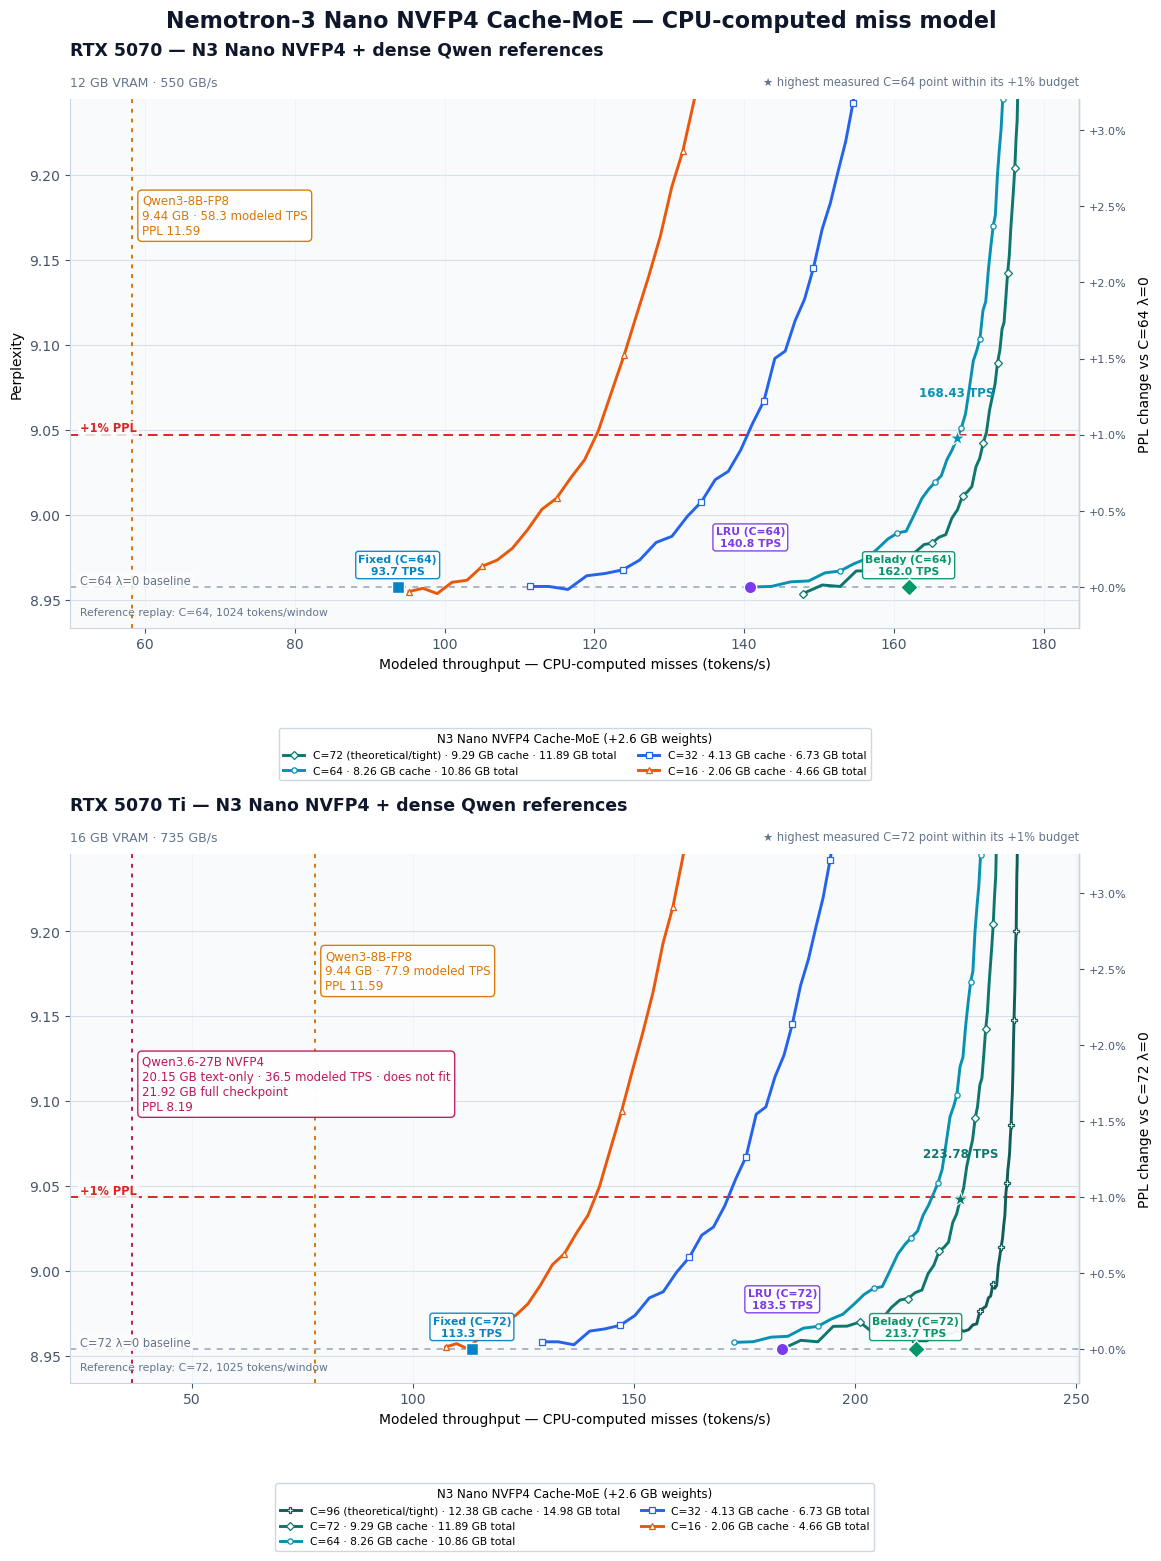

In [6]:
# RTX 5070 / 5070 Ti comparison using the card-specific sweep data above.
def _highest_measured_within_budget(tps, ppl, baseline_ppl, budget_pct=1.0):
    within_budget = ppl <= baseline_ppl * (1.0 + budget_pct / 100.0)
    if not np.any(within_budget):
        return None
    eligible = np.flatnonzero(within_budget)
    return int(eligible[np.argmax(tps[eligible])])


# Dense baselines use a one-full-weight-read-per-token bandwidth proxy.
DENSE_BASELINES = {
    "qwen8": {
        "label": "Qwen3-8B-FP8",
        "weights_gb": 9.44,
        "ppl": 11.593261065274481,
        "color": "#d97706",
    },
    "qwen36": {
        "label": "Qwen3.6-27B NVFP4",
        "weights_gb": 20.15,
        "full_checkpoint_gb": 21.92,
        "size_label": "20.15 GB text-only",
        "fit_note": "does not fit",
        "ppl": 8.185487762450764,
        "color": "#be185d",
    },
}
N3_NVFP4_BASE_WEIGHTS_GB = 2.6
N3_NVFP4_GB_PER_CACHED_EXPERT = 0.129

CACHE_HIT_RATES = {
    16: {"Fixed": 0.126432, "LRU": 0.514842, "Belady": 0.689639},
    32: {"Fixed": 0.241790, "LRU": 0.659928, "Belady": 0.817454},
    64: {"Fixed": 0.498838, "LRU": 0.838717, "Belady": 0.926991},
    72: {"Fixed": 0.559712, "LRU": 0.870719, "Belady": 0.941612},
    96: {"Fixed": 0.756529, "LRU": 0.941499, "Belady": 0.969033},
}
HIT_RATE_REPLAY_TOKENS = {16: 1024, 32: 1024, 64: 1024, 72: 1025, 96: 1025}
REFERENCE_CAPACITY = {"5070": 64, "5070 Ti": 72}


def _n3_cache_label(capacity, card):
    cache_gb = capacity * N3_NVFP4_GB_PER_CACHED_EXPERT
    total_gb = N3_NVFP4_BASE_WEIGHTS_GB + cache_gb
    tight = (card == "5070" and capacity == 72) or (card == "5070 Ti" and capacity == 96)
    qualifier = " (theoretical/tight)" if tight else ""
    return (
        f"C={capacity}{qualifier} · {cache_gb:.2f} GB cache · "
        f"{total_gb:.2f} GB total"
    )


def _plot_card(ax, card, dense_models=()):
    card_data = CACHE_CAPACITY_SWEEP[card]
    capacities = sorted(
        (capacity for capacity in card_data if CACHE_CAPACITY_FITS[card][capacity]),
        reverse=True,
    )
    baseline_ppl = {
        capacity: float(card_data[capacity][0][1]) for capacity in capacities
    }
    budget_ppl = {capacity: value * 1.01 for capacity, value in baseline_ppl.items()}
    lower_ppl = min(baseline_ppl.values()) - 0.02
    upper_ppl = max(value * 1.032 for value in baseline_ppl.values())

    colors = {
        96: "#115e59",
        72: "#0f766e",
        64: "#0891b2",
        32: "#2563eb",
        16: "#ea580c",
    }
    markers = {96: "P", 72: "D", 64: "o", 32: "s", 16: "^"}

    ax.set_facecolor("#f8fafc")
    reference_capacity = REFERENCE_CAPACITY[card]
    reference_baseline = baseline_ppl[reference_capacity]
    one_pct_line = budget_ppl[reference_capacity]
    ax.axhline(
        reference_baseline, color="#94a3b8", linewidth=1.1,
        linestyle=(0, (4, 4)), zorder=1,
    )
    ax.text(
        0.01, reference_baseline,
        f"C={reference_capacity} λ=0 baseline",
        transform=ax.get_yaxis_transform(), ha="left", va="bottom",
        color="#64748b", fontsize=8.2,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5),
    )
    ax.axhline(
        one_pct_line, color="#dc2626", linewidth=1.4,
        linestyle=(0, (5, 3)), zorder=1,
    )
    ax.text(
        0.01, one_pct_line, "+1% PPL",
        transform=ax.get_yaxis_transform(), ha="left", va="bottom",
        color="#dc2626", fontsize=8.2, fontweight="semibold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5),
    )
    ax.text(
        1.0, 1.02,
        f"★ highest measured C={reference_capacity} point within its +1% budget",
        transform=ax.transAxes, ha="right", va="bottom",
        color="#64748b", fontsize=8.2, clip_on=False,
    )

    visible_tps = []
    for label_index, capacity in enumerate(capacities):
        values = np.asarray(card_data[capacity], dtype=float)
        tps, ppl = values[:, 3], values[:, 1]
        color = colors[capacity]
        ax.plot(
            tps, ppl, color=color, linewidth=2.1,
            label=_n3_cache_label(capacity, card),
            marker=markers[capacity], markersize=3.8, markevery=5,
            markerfacecolor="white", markeredgewidth=0.9, zorder=2,
        )
        visible_tps.extend(tps[ppl <= upper_ppl])

        operating_index = _highest_measured_within_budget(
            tps, ppl, baseline_ppl[capacity]
        )
        if capacity == reference_capacity and operating_index is not None:
            operating_tps = float(tps[operating_index])
            operating_ppl = float(ppl[operating_index])
            ax.scatter(
                operating_tps, operating_ppl, marker="*", s=135, color=color,
                edgecolors="white", linewidths=0.8, zorder=4,
            )
            ax.annotate(
                f"{operating_tps:.2f} TPS", xy=(operating_tps, operating_ppl),
                xytext=(0, 10 + 18 * (label_index % 3)), textcoords="offset points",
                ha="center", va="bottom", color=color,
                fontsize=8.5, fontweight="semibold",
            )

    reference_capacity = REFERENCE_CAPACITY[card]
    reference_ppl = baseline_ppl[reference_capacity]
    reference_styles = {
        "Fixed": ("s", "#0284c7", 8),
        "LRU": ("o", "#7c3aed", 28),
        "Belady": ("D", "#059669", 8),
    }
    for policy, hit_rate in CACHE_HIT_RATES[reference_capacity].items():
        marker, color, y_offset = reference_styles[policy]
        reference_tps = float(throughput_proxy(1.0 - hit_rate, card=card, cpu=True))
        visible_tps.append(reference_tps)
        ax.scatter(
            reference_tps, reference_ppl, marker=marker, s=80, color=color,
            edgecolors="white", linewidths=1.0, zorder=5,
        )
        ax.annotate(
            f"{policy} (C={reference_capacity})\n{reference_tps:.1f} TPS",
            xy=(reference_tps, reference_ppl),
            xytext=(0, y_offset), textcoords="offset points",
            ha="center", va="bottom", color=color, fontsize=7.8,
            fontweight="semibold",
            bbox=dict(
                boxstyle="round,pad=0.25", facecolor="white",
                edgecolor=color, alpha=0.94,
            ),
        )

    dense_label_heights = {"qwen8": 0.82, "qwen36": 0.62}
    for model_key in dense_models:
        model = DENSE_BASELINES[model_key]
        model_tps = model.get("modeled_tps", {}).get(
            card, CARD_SPECS[card]["bandwidth_gbps"] / model["weights_gb"]
        )
        visible_tps.append(model_tps)
        ax.axvline(
            model_tps, color=model["color"], linewidth=1.4,
            linestyle=(0, (2, 3)), zorder=1,
        )
        ppl_text = f"\nPPL {model['ppl']:.2f}" if model["ppl"] is not None else "\nPPL not measured"
        size_label = model.get("size_label", f"{model['weights_gb']:.2f} GB")
        fit_text = f" · {model['fit_note']}" if model.get("fit_note") else ""
        checkpoint_text = (
            f"\n{model['full_checkpoint_gb']:.2f} GB full checkpoint"
            if model.get("full_checkpoint_gb") else ""
        )
        ax.annotate(
            f"{model['label']}\n{size_label} · {model_tps:.1f} modeled TPS{fit_text}"
            f"{checkpoint_text}{ppl_text}",
            xy=(model_tps, dense_label_heights[model_key]),
            xycoords=("data", "axes fraction"),
            xytext=(7, 0), textcoords="offset points", ha="left", va="top",
            color=model["color"], fontsize=8.5,
            bbox=dict(
                boxstyle="round,pad=0.35", facecolor="white",
                edgecolor=model["color"], alpha=0.96,
            ),
        )

    x_min, x_max = min(visible_tps), max(visible_tps)
    x_pad = max(5.0, 0.07 * (x_max - x_min))
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(lower_ppl, upper_ppl)
    pct_axis = ax.secondary_yaxis(
        "right",
        functions=(
            lambda value: 100.0 * (np.asarray(value) / reference_baseline - 1.0),
            lambda pct: reference_baseline * (1.0 + np.asarray(pct) / 100.0),
        ),
    )
    pct_ticks = np.arange(0.0, 3.01, 0.5)
    pct_axis.set_yticks(pct_ticks)
    pct_axis.set_yticklabels([f"{value:+.1f}%" for value in pct_ticks])
    pct_axis.set_ylabel(f"PPL change vs C={reference_capacity} λ=0", labelpad=8)
    pct_axis.tick_params(colors="#475569", labelsize=8)
    pct_axis.spines["top"].set_visible(False)

    dense_suffix = " + dense Qwen references" if dense_models else ""
    ax.set_title(
        f"RTX {card} — N3 Nano NVFP4{dense_suffix}",
        loc="left", pad=32, fontsize=12.5, fontweight="bold", color="#0f172a",
    )
    specs = CARD_SPECS[card]
    ax.text(
        0.0, 1.02, f"{specs['vram_gb']} GB VRAM · {specs['bandwidth_gbps']} GB/s",
        transform=ax.transAxes, ha="left", va="bottom",
        color="#64748b", fontsize=9, clip_on=False,
    )
    reference_capacity = REFERENCE_CAPACITY[card]
    ax.text(
        0.01, 0.02,
        f"Reference replay: C={reference_capacity}, "
        f"{HIT_RATE_REPLAY_TOKENS[reference_capacity]} tokens/window",
        transform=ax.transAxes, ha="left", va="bottom",
        color="#64748b", fontsize=7.8,
    )
    ax.set_xlabel("Modeled throughput — CPU-computed misses (tokens/s)")
    ax.grid(axis="y", color="#cbd5e1", linewidth=0.8, alpha=0.7)
    ax.grid(axis="x", color="#e2e8f0", linewidth=0.6, alpha=0.45)
    ax.set_axisbelow(True)
    ax.tick_params(colors="#475569")
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2,
        title=f"N3 Nano NVFP4 Cache-MoE (+{N3_NVFP4_BASE_WEIGHTS_GB:.1f} GB weights)",
        framealpha=0.95, facecolor="white", edgecolor="#cbd5e1",
        fontsize=7.7, title_fontsize=8.5,
    )
    for spine in ax.spines.values():
        spine.set_color("#cbd5e1")
    ax.spines["top"].set_visible(False)
    return baseline_ppl


fig, axes = plt.subplots(2, 1, figsize=(11.5, 15.5), sharey=False, layout="constrained")
fig.patch.set_facecolor("white")
_plot_card(axes[0], "5070", dense_models=("qwen8",))
_plot_card(axes[1], "5070 Ti", dense_models=("qwen8", "qwen36"))
axes[0].set_ylabel("Perplexity")

_ = fig.suptitle(
    "Nemotron-3 Nano NVFP4 Cache-MoE — CPU-computed miss model",
    fontsize=16, fontweight="bold", color="#0f172a",
)